# 🏢 IBM HR Analytics: Employee Attrition Prediction
## Predicting Employee Attrition Using Machine Learning & Deep Learning

This project focuses on understanding employee attrition patterns and building an intelligent prediction system to identify employees who may be at higher risk of leaving the company.

Instead of only training a machine learning model, this project aims to combine:

- Business understanding
- Exploratory Data Analysis (EDA)
- Statistical thinking
- Machine Learning
- Deep Learning
- Model evaluation
- Business-focused decision making

The ultimate goal is to help organizations better understand employee behavior and improve retention strategies.

# 🎯 1. Business Problem

Employee attrition is one of the major challenges faced by organizations.

When employees leave a company, businesses may experience:

- Higher hiring costs
- Training expenses
- Productivity loss
- Team disruption
- Reduced organizational stability

Understanding why employees leave and predicting attrition risk can help organizations make proactive decisions and improve employee retention.

# 🚀 2. Project Goal

The main objective of this project is to build an employee attrition prediction system using Machine Learning and Deep Learning techniques.

The project aims to answer important business questions such as:

- Why do employees leave?
- Which factors are associated with employee attrition?
- Can we predict employees at risk of leaving?
- Which business insights may help improve retention?

Success in this project will not only be measured by model performance, but also by business understanding and interpretability.

# 🛠️ 3. Import Libraries

In this section, we import all required libraries for:

- Data manipulation
- Data visualization
- Statistical analysis
- Machine Learning
- Deep Learning
- Model evaluation

In [1]:
# ==========================================
# Data Manipulation
# ==========================================
import pandas as pd
import numpy as np

# ==========================================
# Data Visualization
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# Statistical Analysis
# ==========================================
from scipy.stats import ttest_ind

# ==========================================
# Machine Learning
# ==========================================
from sklearn.model_selection import (
    train_test_split
)

from sklearn.preprocessing import (
    StandardScaler
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

# ==========================================
# Deep Learning (PyTorch)
# ==========================================
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import (
    TensorDataset,
    DataLoader
)

# ==========================================
# Warnings
# ==========================================
import warnings
warnings.filterwarnings("ignore")

# 📂 4. Load Dataset

In this section, we load the IBM Employee Attrition dataset and create a working copy for further analysis.

We also keep a raw version of the dataset for business analysis and exploratory data analysis (EDA).

In [2]:
df = pd.read_csv(r"C:\Users\mahmu\OneDrive\Desktop\IBM Employee Attrition\data\WA_Fn-UseC_-HR-Employee-Attrition.csv")

# Keep raw copy for business EDA
df_raw = df.copy()

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


# 🔎 5. Dataset Overview

Before building any machine learning model, it is important to understand the structure of the dataset.

In this section, we explore:

- Dataset dimensions
- Data types
- Missing values
- Numerical vs categorical features
- General structure of the data

The goal is to better understand the dataset before moving into business analysis and preprocessing.

## 5.1 Dataset Information

We inspect the dataset structure to understand:

- Number of rows and columns
- Feature names
- Data types
- Missing values

In [3]:
print("=" * 50)
print("Dataset Shape:", df.shape)
print("=" * 50)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Info:")
df.info()

Dataset Shape: (1470, 35)

Column Names:
['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTrav

## 5.2 Missing Values Check

Missing values can negatively affect model performance and data analysis.

In this section, we check whether the dataset contains missing values that may require handling before modeling.

In [4]:
missing_values = df.isnull().sum()

missing_values[
    missing_values > 0
].sort_values(
    ascending=False
)

Series([], dtype: int64)

### Key Observation

The dataset contains no missing values.

This simplifies preprocessing and allows us to focus more on:

- Business understanding
- Feature engineering
- Statistical analysis
- Model performance improvement

# 🧠 6. Data Understanding

Before moving into modeling, it is important to understand what each feature represents and how it may relate to employee attrition.

At this stage, we begin thinking from both:

- Business perspective
- Machine learning perspective

Main questions:

- Which features may influence attrition?
- Which variables may be less useful?
- Which features are numerical or categorical?
- Are there any suspicious or constant features?

## 6.1 Numerical vs Categorical Features

To better understand the dataset structure, we separate features into:

- Numerical features
- Categorical features

This helps us prepare for:

- Exploratory Data Analysis (EDA)
- Statistical analysis
- Feature engineering
- Data preprocessing

In [5]:
numerical_features = df.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = df.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical Features Count:",
      len(numerical_features))

print("Categorical Features Count:",
      len(categorical_features))

print("\nNumerical Features:")
print(numerical_features)

print("\n" + "=" * 60)

print("Categorical Features:")
print(categorical_features)

Numerical Features Count: 26
Categorical Features Count: 9

Numerical Features:
['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

Categorical Features:
['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime']


## 6.2 Suspicious Features Check

Some features may provide little or no useful information for prediction.

In this section, we inspect potentially suspicious columns to determine whether they should be removed later.

Examples include:

- Constant features
- Unique identifiers
- Low-information variables

In [6]:
suspicious_features = [
    "EmployeeCount",
    "EmployeeNumber",
    "StandardHours"
]

for col in suspicious_features:

    print("=" * 50)
    print(col)
    print("=" * 50)

    print(df[col].value_counts())

    print("\n")

EmployeeCount
EmployeeCount
1    1470
Name: count, dtype: int64


EmployeeNumber
EmployeeNumber
1       1
2       1
4       1
5       1
7       1
       ..
2061    1
2062    1
2064    1
2065    1
2068    1
Name: count, Length: 1470, dtype: int64


StandardHours
StandardHours
80    1470
Name: count, dtype: int64




## 6.3 Suspicious Features Findings

Based on the initial inspection, some features appear to provide little or no predictive value.

### Features likely to be removed later:

#### 1. EmployeeCount
This feature contains only one constant value across all employees.

Since it does not vary, it provides no useful information for prediction.

#### 2. StandardHours
This feature contains the same value for every employee.

As a constant feature, it is unlikely to contribute meaningful predictive signal.

#### 3. EmployeeNumber
This feature behaves as a unique identifier.

Since every employee has a different number, it is unlikely to help model generalization and may introduce unnecessary noise.

These features will be reconsidered during preprocessing before model training.

# 🎯 7. Target Analysis

Before building any predictive model, it is important to understand the target variable.

In this project, the target variable is:

> **Attrition**

This feature indicates whether an employee leaves the company or stays.

At this stage, we aim to understand:

- Class distribution
- Attrition ratio
- Whether class imbalance exists
- Potential implications for modeling

## 7.1 Attrition Distribution

In this section, we analyze the distribution of employee attrition.

Understanding class balance is important because heavily imbalanced datasets may affect model learning and evaluation.

This helps us answer:

- How many employees leave the company?
- How many employees stay?
- Is class imbalance present?

In [7]:
attrition_counts = df["Attrition"].value_counts()

print(attrition_counts)

Attrition
No     1233
Yes     237
Name: count, dtype: int64


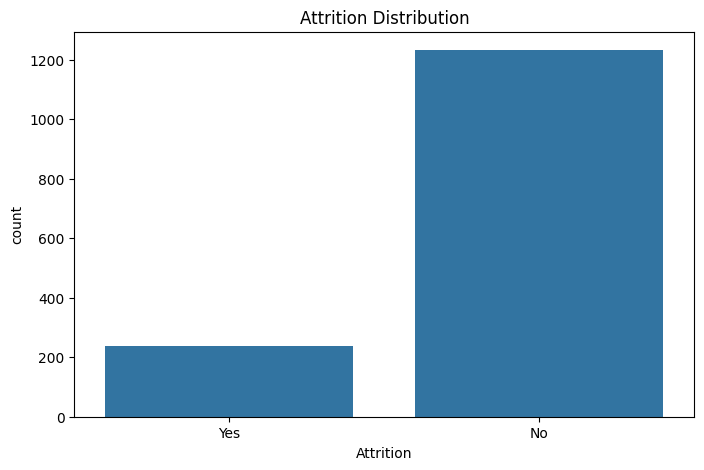

In [8]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Attrition"
)

plt.title("Attrition Distribution")

plt.show()

In [9]:
attrition_percentage = (
    df["Attrition"]
    .value_counts(normalize=True)
    * 100
)

print(
    attrition_percentage
    .round(2)
)

Attrition
No     83.88
Yes    16.12
Name: proportion, dtype: float64


## 7.2 Business Interpretation

Based on the target analysis:

- Employees staying in the company (**No Attrition**) represent approximately **83.88%** of the dataset.
- Employees leaving the company (**Yes Attrition**) represent only **16.12%**.

This indicates a clear **class imbalance problem**.

Why does this matter?

In imbalanced datasets, models may become biased toward the majority class.

For example:

A model predicting:

> "No Attrition" for every employee

would still achieve relatively high accuracy.

However, such a model would fail to identify employees actually at risk of leaving.

Therefore, relying only on **accuracy** may be misleading in this project.

Metrics such as:

- Recall
- Precision
- F1 Score
- ROC-AUC

will become especially important during evaluation.

# 📊 8. Advanced Business EDA

At this stage, we move beyond basic dataset understanding and begin exploring potential business patterns related to employee attrition.

The purpose of this analysis is to investigate:

- Which employee characteristics may relate to attrition
- Which features appear more informative
- Possible business risk factors
- Early predictive signals before modeling

Rather than focusing only on machine learning performance, this section emphasizes business understanding and interpretability.

## 8.1 Numerical Features Analysis

In this section, we analyze important numerical features to investigate whether employees who leave the company show different behavioral or employment-related patterns.

Main questions:

- Do younger employees leave more often?
- Does salary affect attrition?
- Does company tenure matter?
- Is job satisfaction related to attrition?
- Do more experienced employees stay longer?

In [10]:
numerical_features = [
    "Age",
    "MonthlyIncome",
    "DistanceFromHome",
    "YearsAtCompany",
    "JobSatisfaction",
    "TotalWorkingYears"
]

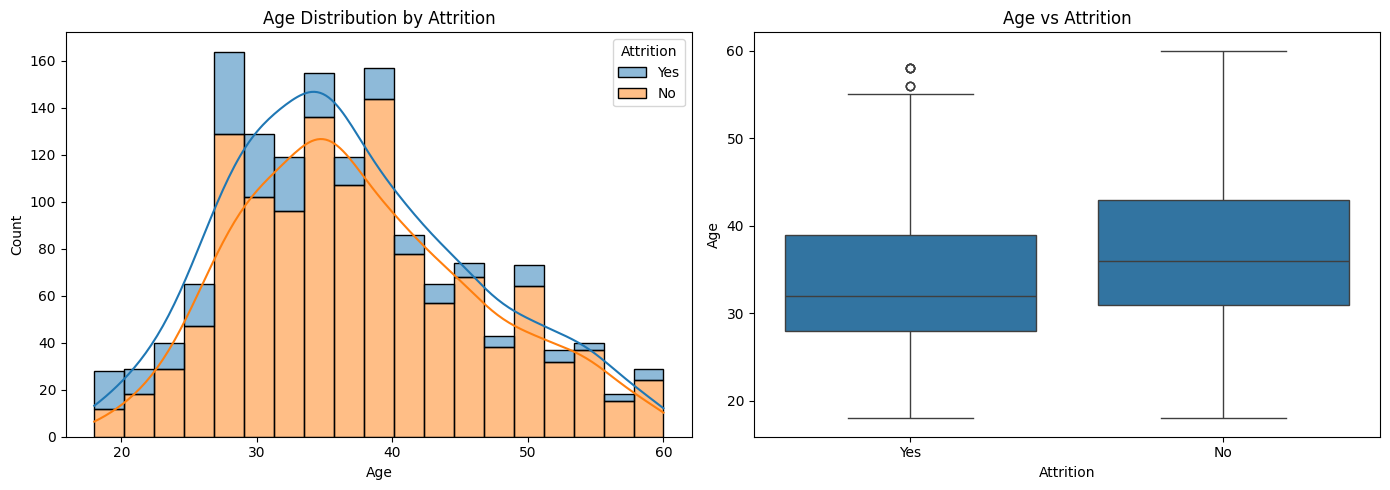

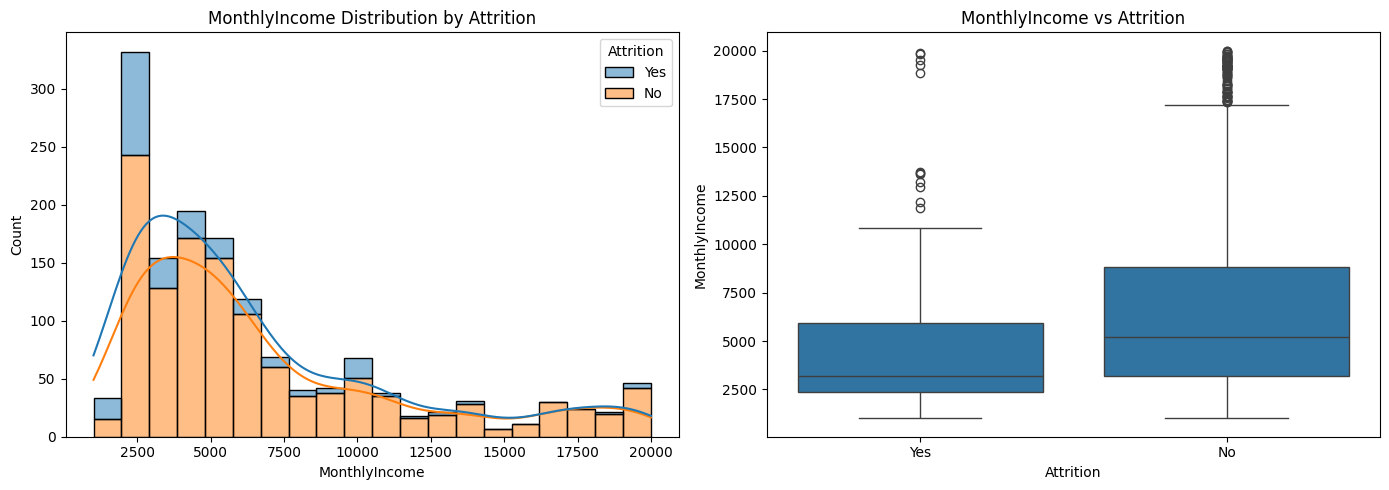

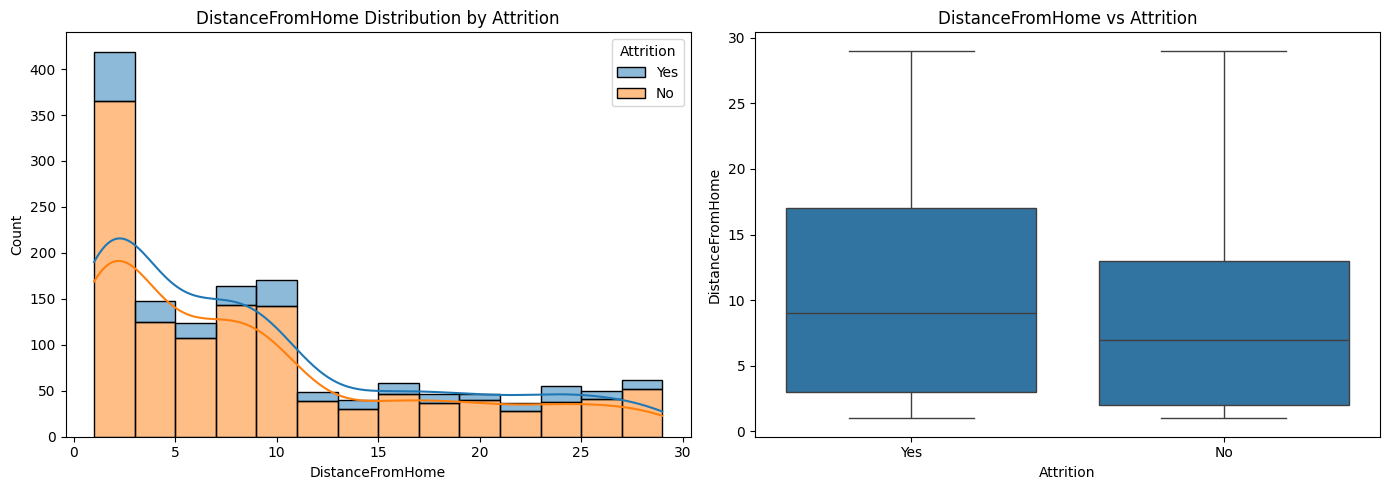

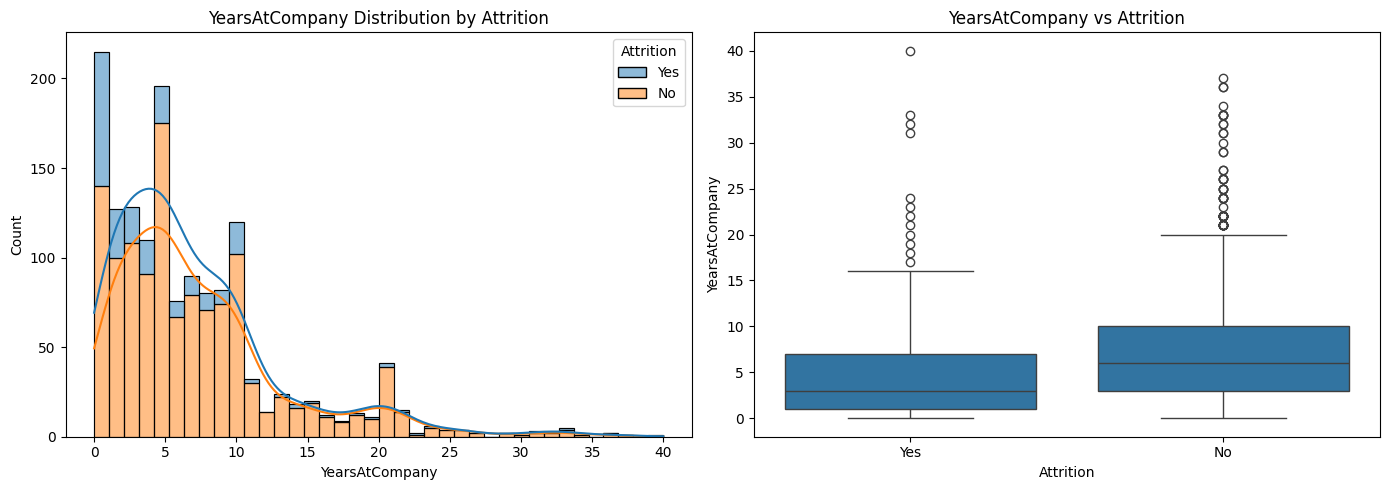

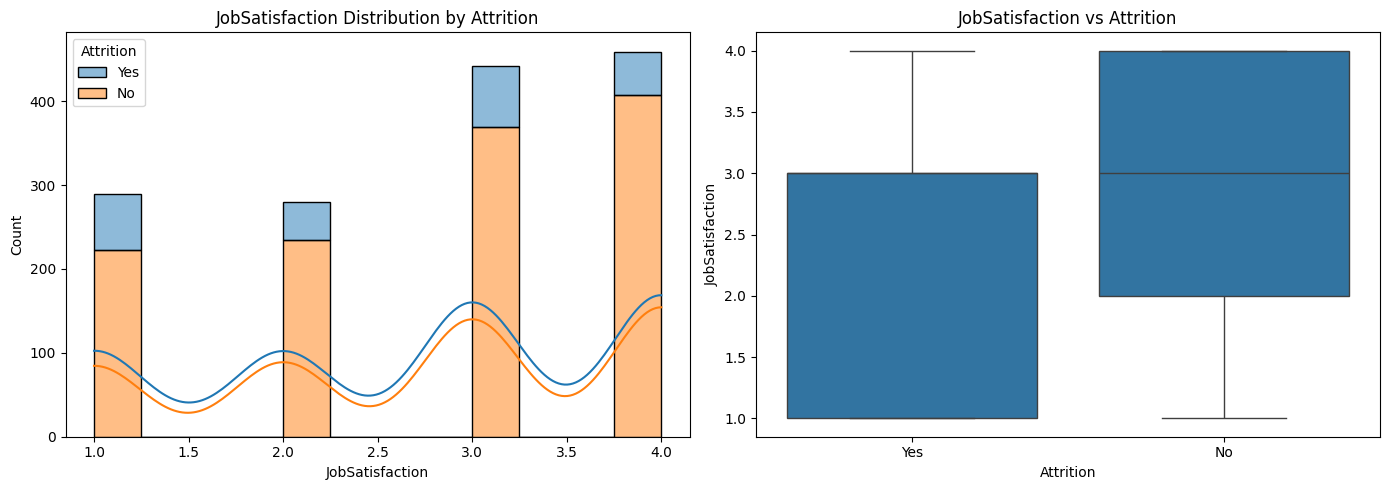

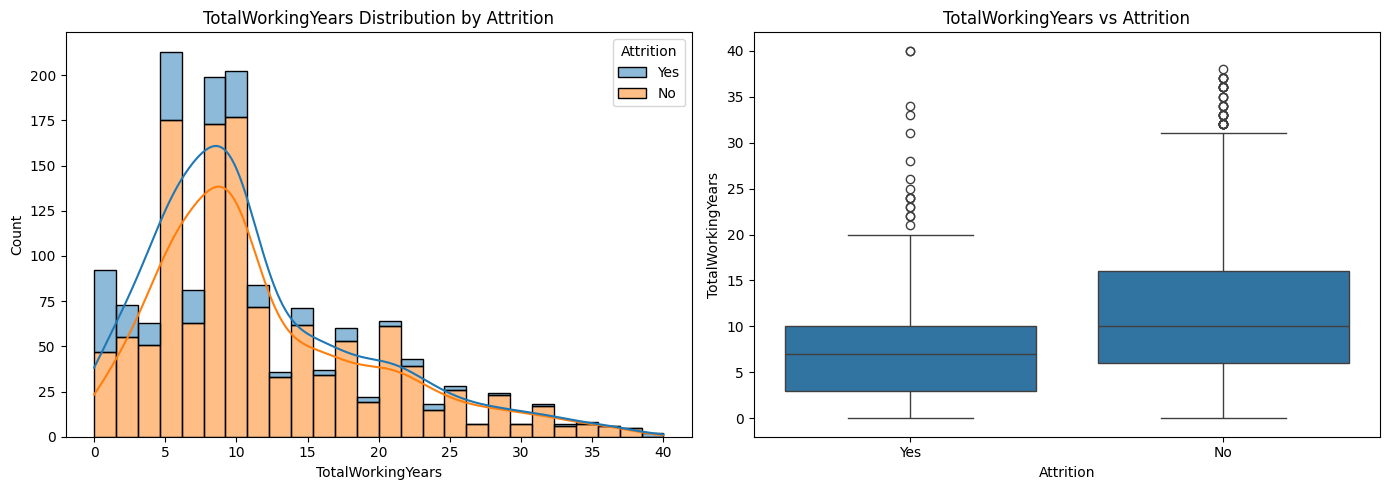

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

for feature in numerical_features:

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(14, 5)
    )

    # Distribution
    sns.histplot(
        data=df_raw,
        x=feature,
        hue="Attrition",
        kde=True,
        multiple="stack",
        ax=axes[0]
    )

    axes[0].set_title(
        f"{feature} Distribution by Attrition"
    )

    # Boxplot
    sns.boxplot(
        data=df_raw,
        x="Attrition",
        y=feature,
        ax=axes[1]
    )

    axes[1].set_title(
        f"{feature} vs Attrition"
    )

    plt.tight_layout()
    plt.show()

## 8.2 Numerical Business Insights

### 1. Age

Employees who leave the company appear to be slightly younger on average.

The median age for attrition employees is lower than employees who stay, suggesting younger employees may be more likely to leave.

However, substantial overlap exists between both groups, meaning age alone is unlikely to be a strong standalone predictor of attrition.

Overall, age appears to provide a moderate predictive signal.

---

### 2. Monthly Income

Employees who leave the company generally appear to have lower monthly income.

The attrition group shows a noticeably lower median salary compared to employees who stay.

Although overlap still exists between both groups, income appears to provide a meaningful predictive signal.

This suggests lower salary may be associated with increased attrition risk.

Overall, monthly income appears to be a relatively strong feature.

---

### 3. Distance From Home

Distance from home does not show strong separation between employees who leave and those who stay.

The distributions and median values appear relatively similar between both groups.

Although employees who leave may show slightly higher commuting distance, the overlap is substantial.

This suggests distance from home is likely a weak standalone predictor.

---

### 4. Years At Company

Employees with lower tenure appear significantly more likely to leave the company.

The attrition group is more concentrated among employees with fewer years at the company.

Employees staying in the company generally show longer tenure.

This suggests employee retention risk may be higher during early employment stages.

Years at company appears to be one of the strongest predictive signals.

---

### 5. Job Satisfaction

Employees who leave the company tend to have lower job satisfaction.

Attrition employees appear more concentrated in lower satisfaction levels, while employees who stay tend to show higher satisfaction.

This suggests job satisfaction may be an important business-related factor influencing employee attrition.

Overall, job satisfaction appears to be a strong predictive feature.

---

### 6. Total Working Years

Employees who leave the company generally appear to have fewer total working years.

More experienced employees seem relatively more stable within the company.

However, overlap still exists between groups, meaning this feature alone may not fully explain attrition.

Overall, total working years appears to provide a moderate predictive signal.

## 8.3 Categorical Features Analysis

In this section, we analyze important categorical features to investigate whether employee attrition differs across categories.

The goal is to identify possible business-related patterns and employee groups that may show higher attrition risk.

Main questions:

- Is overtime associated with higher attrition?
- Are some departments more affected?
- Do specific job roles show higher attrition risk?
- Does marital status influence employee retention?
- Does business travel relate to attrition?

In [12]:
categorical_features = [
    "OverTime",
    "Department",
    "JobRole",
    "MaritalStatus",
    "BusinessTravel"
]

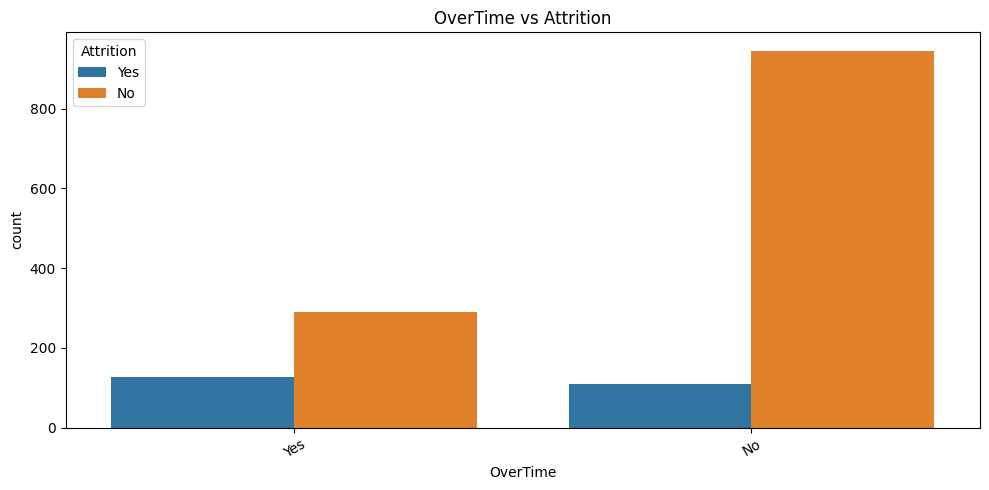

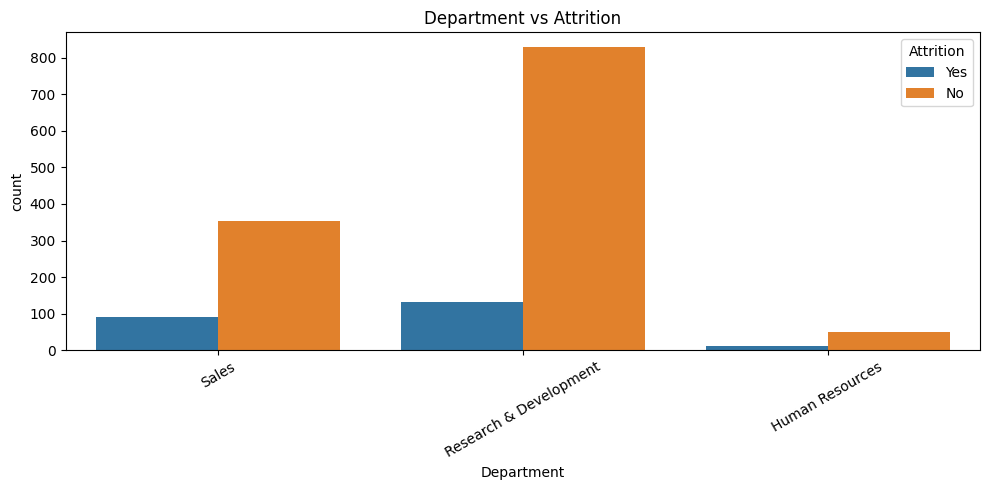

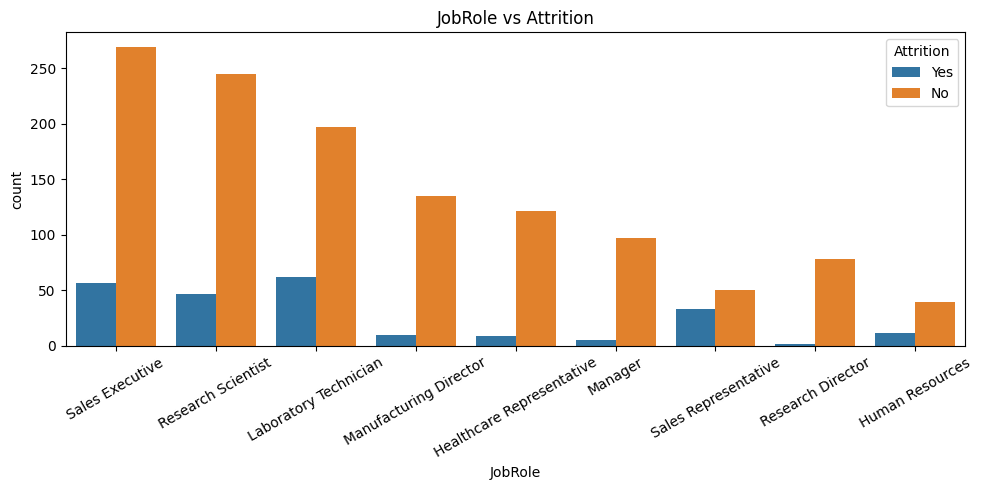

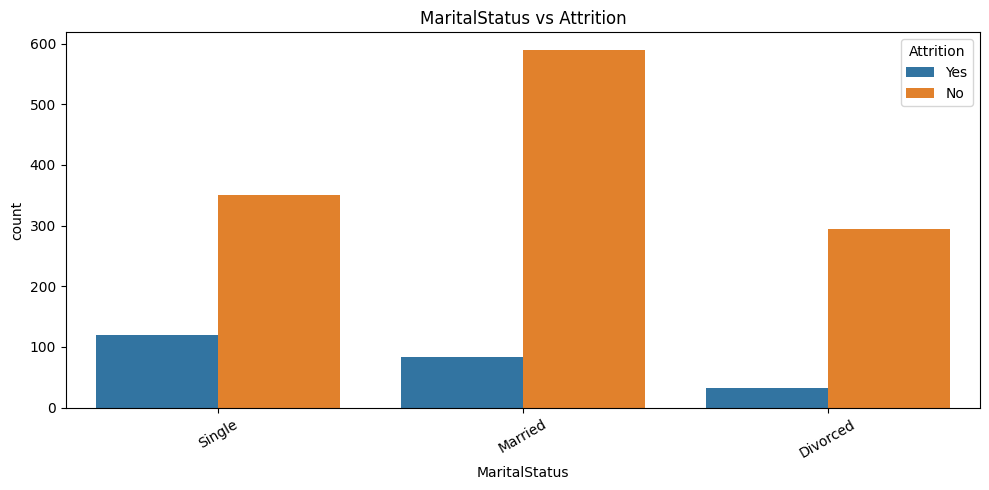

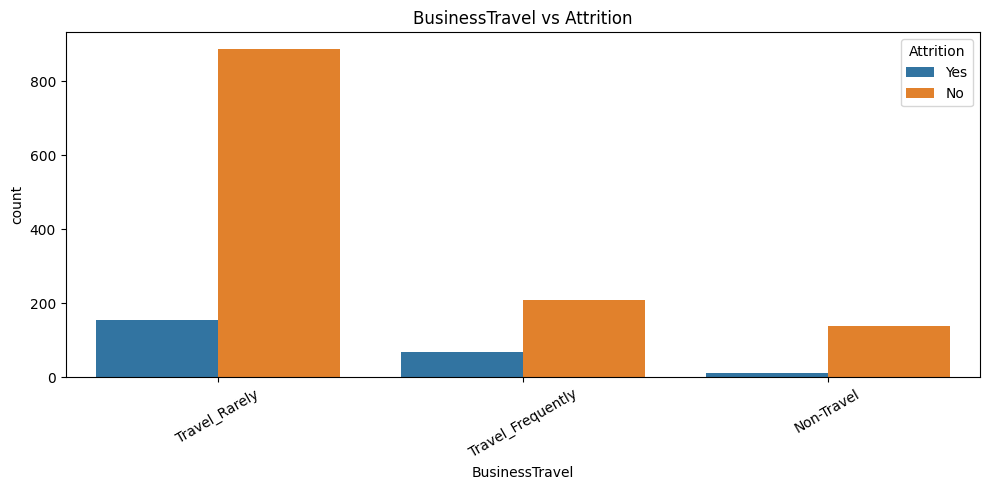

In [13]:
for feature in categorical_features:

    plt.figure(figsize=(10, 5))

    sns.countplot(
        data=df_raw,
        x=feature,
        hue="Attrition"
    )

    plt.title(
        f"{feature} vs Attrition"
    )

    plt.xticks(rotation=30)

    plt.tight_layout()

    plt.show()

## 8.4 Categorical Business Insights

### 1. OverTime

Overtime appears strongly associated with employee attrition.

Employees working overtime show noticeably higher attrition counts compared to employees who do not work overtime.

This suggests overtime may be one of the strongest business risk factors affecting employee retention.

Overall, overtime appears to be a very strong predictive signal.

---

### 2. Department

Research & Development and Sales departments show higher attrition counts compared to Human Resources.

However, this may partly reflect department size differences.

A fairer comparison requires analyzing attrition percentages within each department.

At this stage, department appears to provide moderate predictive signal.

---

### 3. Job Role

Some job roles appear to experience higher attrition counts.

In particular:

- Sales Executive
- Laboratory Technician
- Research Scientist

However, role population size may influence these observations.

Further percentage-based analysis is required.

Job role appears potentially important.

---

### 4. Marital Status

Single employees appear more likely to leave the company compared to married employees.

Married employees seem relatively more stable.

This may suggest personal stability influences employee retention.

Marital status appears moderately informative.

---

### 5. Business Travel

Employees who travel frequently may show higher attrition compared to non-travel employees.

Frequent travel could contribute to stress, burnout, or lower work-life balance.

Business travel may provide useful predictive signal.

## 8.5 Attrition Rate by Category

Raw counts alone may be misleading because some categories contain more employees than others.

To better understand employee attrition risk, we calculate:

> Attrition percentage inside each category

This provides a fairer business comparison across employee groups.

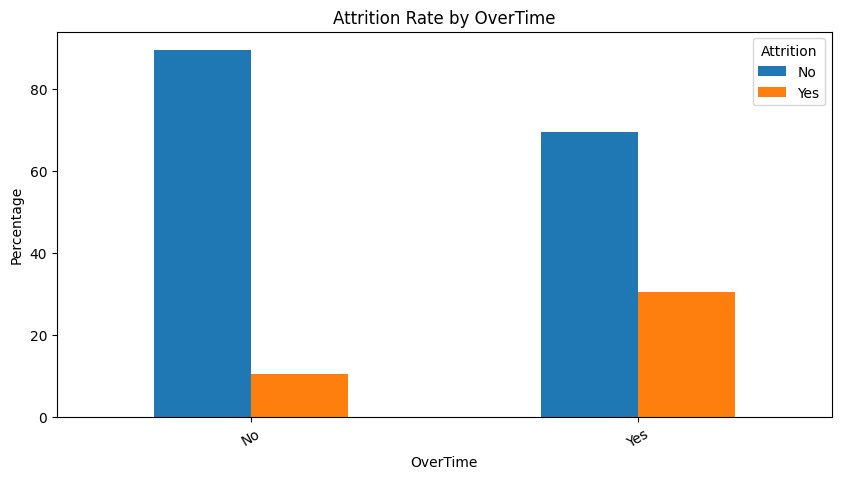

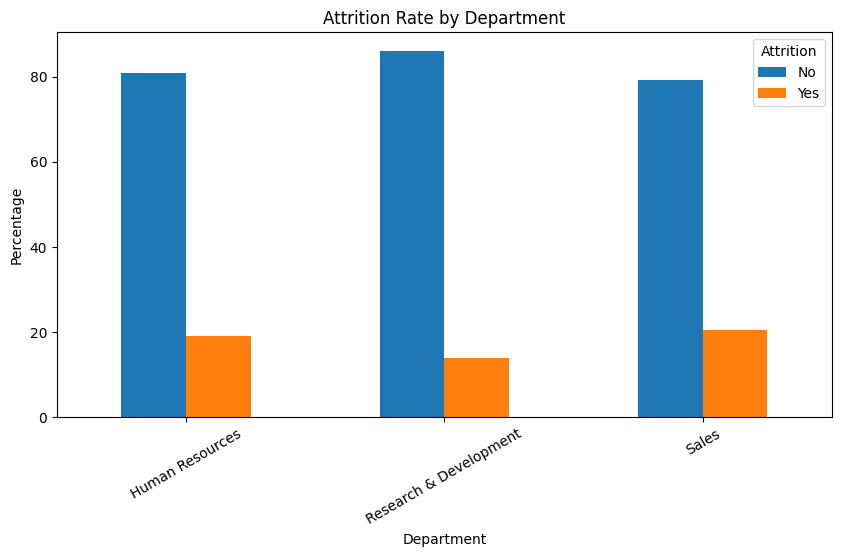

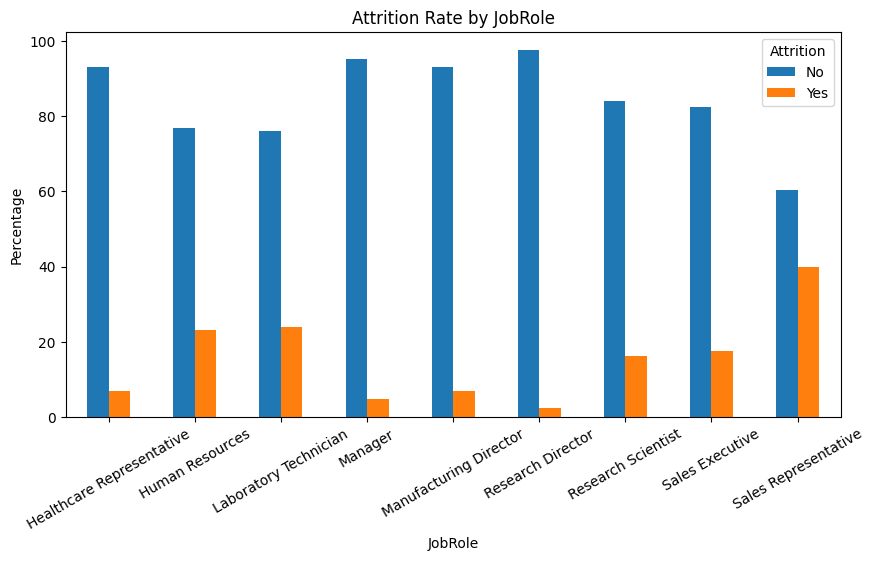

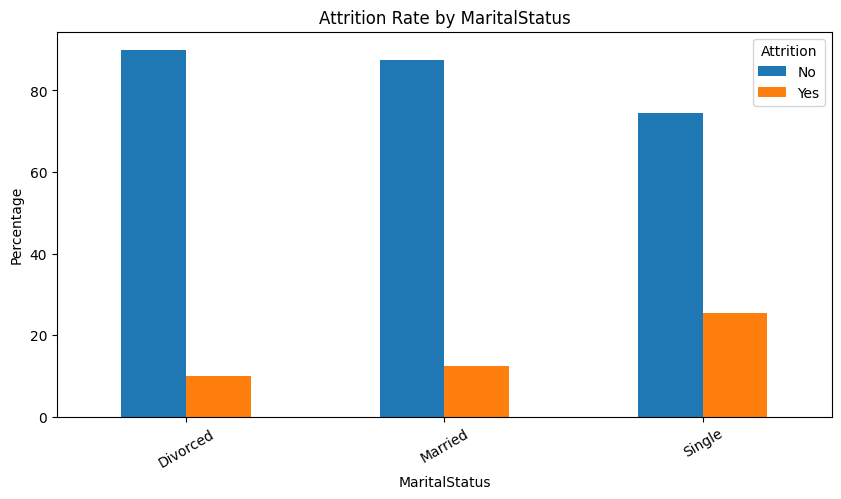

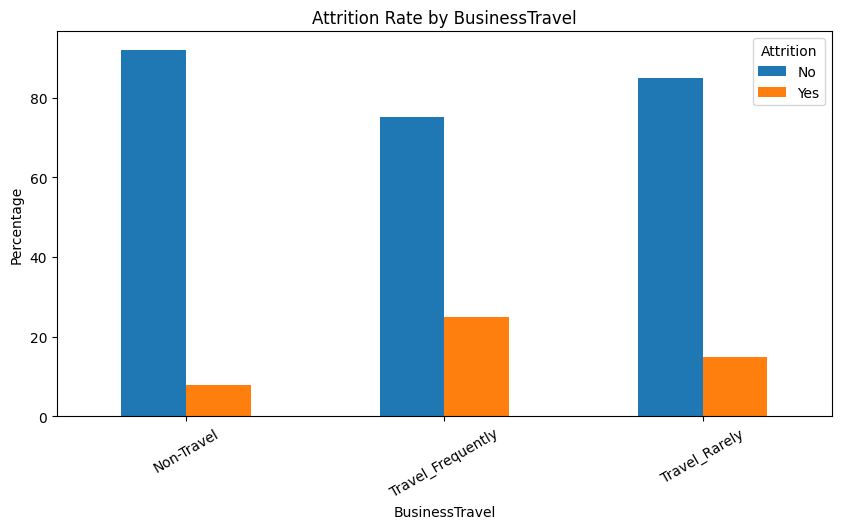

In [14]:
important_categories = [
    "OverTime",
    "Department",
    "JobRole",
    "MaritalStatus",
    "BusinessTravel"
]

for feature in important_categories:

    attrition_rate = pd.crosstab(
        df_raw[feature],
        df_raw["Attrition"],
        normalize="index"
    ) * 100

    attrition_rate.plot(
        kind="bar",
        figsize=(10, 5)
    )

    plt.title(
        f"Attrition Rate by {feature}"
    )

    plt.ylabel("Percentage")

    plt.xticks(rotation=30)

    plt.show()

## 8.6 Final Categorical Business Insights

### 1. OverTime

Overtime appears to be one of the strongest predictors of attrition.

Employees working overtime show dramatically higher attrition rates compared to employees who do not work overtime.

Approximate observation:

- No Overtime → around 10% attrition
- Overtime → around 30% attrition

This suggests overtime may significantly increase employee burnout and turnover risk.

Overall, overtime appears to be an extremely strong predictive feature.

---

### 2. Department

Department-level attrition varies across teams.

Sales and Human Resources appear to show higher attrition rates compared to Research & Development.

Research & Development appears relatively more stable.

However, department alone may not fully explain attrition behavior.

Department appears to provide moderate predictive signal.

---

### 3. Job Role

Job role shows meaningful differences in attrition risk.

Some employee groups appear especially vulnerable:

High-risk job roles:

- Sales Representative
- Laboratory Technician
- Human Resources
- Research Scientist

More stable job roles:

- Research Director
- Manager
- Manufacturing Director

This suggests employee role strongly influences attrition behavior.

Job role appears to be a strong business-related feature.

---

### 4. Marital Status

Single employees appear substantially more likely to leave the company.

Approximate attrition risk:

- Single → highest attrition
- Married → lower attrition
- Divorced → lowest attrition

This may suggest personal stability affects employee retention.

Marital status appears moderately informative.

---

### 5. Business Travel

Employees who travel frequently show noticeably higher attrition risk.

Approximate observation:

- Travel Frequently → highest attrition
- Travel Rarely → moderate attrition
- Non-Travel → lowest attrition

Frequent travel may contribute to stress and lower work-life balance.

Business travel appears to provide strong predictive signal.

# 📈 9. Statistical Validation

Visual patterns are useful, but they are not enough.

At this stage, we statistically validate whether observed differences between employee groups are significant or simply random variation.

Main goal:

> Determine whether observed feature differences are statistically meaningful.

This helps us better understand which features may truly influence employee attrition.

## 9.1 Numerical Features Statistical Testing

To statistically validate numerical feature differences between attrition groups, we use:

> **Mann–Whitney U Test**

This test helps determine whether feature distributions differ significantly between employees who leave and employees who stay.

Why this test?

Because many numerical variables do not appear normally distributed.

In [15]:
from scipy.stats import mannwhitneyu

important_numerical = [
    "Age",
    "MonthlyIncome",
    "DistanceFromHome",
    "YearsAtCompany",
    "JobSatisfaction",
    "TotalWorkingYears"
]

for feature in important_numerical:

    attrition_yes = df_raw[
        df_raw["Attrition"] == "Yes"
    ][feature]

    attrition_no = df_raw[
        df_raw["Attrition"] == "No"
    ][feature]

    stat, p_value = mannwhitneyu(
        attrition_yes,
        attrition_no
    )

    print("=" * 60)
    print(f"Feature: {feature}")

    print(
        f"P-value: {p_value:.6f}"
    )

    if p_value < 0.05:
        print(
            "✅ Statistically Significant"
        )
    else:
        print(
            "❌ Not Significant"
        )

Feature: Age
P-value: 0.000000
✅ Statistically Significant
Feature: MonthlyIncome
P-value: 0.000000
✅ Statistically Significant
Feature: DistanceFromHome
P-value: 0.002387
✅ Statistically Significant
Feature: YearsAtCompany
P-value: 0.000000
✅ Statistically Significant
Feature: JobSatisfaction
P-value: 0.000080
✅ Statistically Significant
Feature: TotalWorkingYears
P-value: 0.000000
✅ Statistically Significant


## 9.2 Statistical Findings Summary

Statistical testing confirms that all selected numerical features show significant differences between employees who leave and employees who stay.

Features with statistically significant differences:

- Age
- MonthlyIncome
- DistanceFromHome
- YearsAtCompany
- JobSatisfaction
- TotalWorkingYears

This suggests that observed patterns from EDA are not random and likely reflect meaningful behavioral or employment-related differences.

However, statistical significance alone does not guarantee strong predictive power.

Further modeling will determine which features contribute most to prediction performance.

## 9.3 Categorical Statistical Testing

To statistically validate categorical feature relationships with attrition, we use:

> **Chi-Square Test of Independence**

This test helps determine whether a categorical feature is significantly associated with employee attrition.

Main goal:

> Determine whether observed categorical patterns are statistically meaningful or random.

In [16]:
from scipy.stats import chi2_contingency

important_categorical = [
    "OverTime",
    "Department",
    "JobRole",
    "MaritalStatus",
    "BusinessTravel"
]

for feature in important_categorical:

    contingency_table = pd.crosstab(
        df_raw[feature],
        df_raw["Attrition"]
    )

    chi2, p_value, dof, expected = (
        chi2_contingency(
            contingency_table
        )
    )

    print("=" * 60)
    print(f"Feature: {feature}")

    print(
        f"P-value: {p_value:.10f}"
    )

    if p_value < 0.05:
        print(
            "✅ Statistically Significant"
        )
    else:
        print(
            "❌ Not Significant"
        )

Feature: OverTime
P-value: 0.0000000000
✅ Statistically Significant
Feature: Department
P-value: 0.0045256066
✅ Statistically Significant
Feature: JobRole
P-value: 0.0000000000
✅ Statistically Significant
Feature: MaritalStatus
P-value: 0.0000000001
✅ Statistically Significant
Feature: BusinessTravel
P-value: 0.0000056086
✅ Statistically Significant


## 9.4 Categorical Statistical Findings

Statistical testing confirms that all selected categorical features show significant association with employee attrition.

Statistically significant categorical features:

- OverTime
- Department
- JobRole
- MaritalStatus
- BusinessTravel

These findings validate the patterns observed during categorical exploratory data analysis (EDA).

In particular:

- Overtime appears strongly associated with attrition
- Certain job roles show higher attrition risk
- Single employees appear more likely to leave
- Frequent business travel may increase turnover risk

However, statistical significance does not necessarily indicate predictive strength.

Modeling and feature importance analysis will later determine which variables contribute most to prediction performance.

# 🛠️ 10. Data Preprocessing

Before building machine learning and deep learning models, the dataset must be prepared properly.

Data preprocessing is important because machine learning algorithms cannot directly work with raw data.

At this stage, we prepare the dataset by:

- Removing low-information features
- Encoding categorical variables
- Defining features and target
- Splitting the dataset
- Scaling numerical variables

The goal is to create a clean and model-ready dataset.

## 10.1 Feature Removal

Based on earlier analysis, some features appear to provide little or no predictive value.

Features removed:

### 1. EmployeeCount
Contains only one constant value across all employees.

### 2. StandardHours
Contains the same value for every employee.

### 3. EmployeeNumber
Acts as a unique identifier and is unlikely to help generalization.

Removing these features helps reduce unnecessary noise during training.

In [17]:
columns_to_drop = [
    "EmployeeCount",
    "StandardHours",
    "EmployeeNumber"
]

df = df.drop(
    columns=columns_to_drop
)

print("New Dataset Shape:")
print(df.shape)

New Dataset Shape:
(1470, 32)


## 10.2 Features vs Target

In supervised machine learning, it is important to separate:

### Features (X)

These are the input variables used by the model to learn patterns.

Examples:

- Age
- MonthlyIncome
- JobRole
- OverTime
- JobSatisfaction

### Target (y)

The target variable represents what we want to predict.

In this project:

> **Attrition**

The model will learn patterns from employee data to predict whether an employee is likely to leave the company.

In [18]:
X = df.drop(
    "Attrition",
    axis=1
)

y = df["Attrition"]

print("Features Shape:")
print(X.shape)

print("\nTarget Shape:")
print(y.shape)

Features Shape:
(1470, 31)

Target Shape:
(1470,)


## 10.3 Target Encoding

Machine learning models cannot directly understand text labels.

Therefore, we convert the target variable:

- No → 0
- Yes → 1

This creates a binary classification target suitable for machine learning and deep learning models.

In [19]:
y = y.map({
    "No": 0,
    "Yes": 1
})

print(
    y.value_counts()
)

Attrition
0    1233
1     237
Name: count, dtype: int64


## 10.4 Feature Encoding

Machine learning models cannot directly understand categorical text features.

Therefore, categorical variables must be converted into numerical representation.

In this project, we use:

> **One-Hot Encoding**

This approach creates binary columns for each category.

Why use One-Hot Encoding?

Because categorical values such as:

- Department
- JobRole
- BusinessTravel

do not have meaningful numerical order.

For example:

Sales ≠ 1  
HR ≠ 2  
Research ≠ 3

Assigning numbers directly may introduce misleading relationships.

One-Hot Encoding avoids this problem.

In [20]:
X = pd.get_dummies(
    X,
    drop_first=True
)

print(
    "Encoded Features Shape:"
)

print(X.shape)

Encoded Features Shape:
(1470, 44)


## 10.5 Train-Test Split

Before training the model, we split the dataset into:

- Training set
- Testing set

Why?

To fairly evaluate model performance on unseen data.

In this project:

- 80% → Training data
- 20% → Testing data

We also use:

> **Stratified Sampling**

to preserve class distribution because employee attrition is imbalanced.

In [21]:
from sklearn.model_selection import (
    train_test_split
)

X_train, X_test, y_train, y_test = (
    train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )
)

print("Training Set Shape:")
print(X_train.shape)

print("\nTesting Set Shape:")
print(X_test.shape)

Training Set Shape:
(1176, 44)

Testing Set Shape:
(294, 44)


## 10.6 Feature Scaling

Numerical features often exist on very different scales.

For example:

- Age → around 20–60
- MonthlyIncome → thousands
- JobSatisfaction → small values

Large differences in feature scale may negatively affect model learning.

To solve this problem, we use:

> **StandardScaler**

This method standardizes features to improve training stability and performance.

Important:

The scaler is fitted only on training data to avoid:

> **Data Leakage**

In [22]:
from sklearn.preprocessing import (
    StandardScaler
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)

print("Training Shape:")
print(X_train_scaled.shape)

print("\nTesting Shape:")
print(X_test_scaled.shape)

Training Shape:
(1176, 44)

Testing Shape:
(294, 44)


## 10.7 Tensor Conversion (PyTorch)

PyTorch models cannot directly work with NumPy arrays or pandas objects.

Therefore, we convert our data into:

> **PyTorch Tensors**

This allows efficient computation and prepares the dataset for neural network training.

In [23]:
X_train_tensor = torch.tensor(
    X_train_scaled,
    dtype=torch.float32
)

X_test_tensor = torch.tensor(
    X_test_scaled,
    dtype=torch.float32
)

y_train_tensor = torch.tensor(
    y_train.values,
    dtype=torch.float32
).view(-1, 1)

y_test_tensor = torch.tensor(
    y_test.values,
    dtype=torch.float32
).view(-1, 1)

print("X_train shape:",
      X_train_tensor.shape)

print("X_test shape:",
      X_test_tensor.shape)

print("y_train shape:",
      y_train_tensor.shape)

print("y_test shape:",
      y_test_tensor.shape)

X_train shape: torch.Size([1176, 44])
X_test shape: torch.Size([294, 44])
y_train shape: torch.Size([1176, 1])
y_test shape: torch.Size([294, 1])


## 10.8 TensorDataset & DataLoader

Training neural networks using the entire dataset at once may be inefficient.

Instead, we divide the data into:

> **Mini-Batches**

This improves:

- Training efficiency
- Memory usage
- Model optimization

In PyTorch, we use:

### TensorDataset
To combine features and targets.

### DataLoader
To create mini-batches during training.

In [24]:
from torch.utils.data import (
    TensorDataset,
    DataLoader
)

In [25]:
train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

test_dataset = TensorDataset(
    X_test_tensor,
    y_test_tensor
)

In [26]:
batch_size = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

print("Batch Size:",
      batch_size)

Batch Size: 32


# 🧠 11. Baseline Neural Network

At this stage, we build our first neural network model.

The purpose of this model is not to achieve the best performance immediately.

Instead, we aim to:

- Build a simple baseline model
- Understand initial performance
- Identify weaknesses
- Create a reference point for future improvements

This baseline will later help us evaluate whether advanced techniques actually improve performance.

## 11.1 Define Neural Network Architecture

We start with a simple neural network architecture.

Model structure:

Input Layer → Hidden Layer → Output Layer

Why start simple?

Because a baseline model should remain interpretable and easy to improve later.

Since employee attrition is a binary classification problem, we use:

> **Sigmoid activation**

to output attrition probability.

In [27]:
class AttritionNN(nn.Module):

    def __init__(self):

        super().__init__()

        self.model = nn.Sequential(

            nn.Linear(44, 32),

            nn.ReLU(),

            nn.Linear(32, 1),

            nn.Sigmoid()
        )

    def forward(self, x):

        return self.model(x)

## 11.2 Model Initialization

After defining the neural network architecture, we initialize:

- Model
- Loss function
- Optimizer

For this baseline model:

### Loss Function
> Binary Cross Entropy Loss (BCELoss)

Because employee attrition is a binary classification problem.

### Optimizer
> Adam Optimizer

Due to its strong performance and training stability.

In [28]:
model = AttritionNN()

criterion = nn.BCELoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

print(model)

AttritionNN(
  (model): Sequential(
    (0): Linear(in_features=44, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=1, bias=True)
    (3): Sigmoid()
  )
)


## 11.3 Model Training

At this stage, the model learns patterns from employee data.

Training works by:

1. Making predictions
2. Calculating error (loss)
3. Updating model weights
4. Repeating the process over multiple epochs

The objective is to gradually improve prediction performance over time.

In [29]:
epochs = 100

train_losses = []

for epoch in range(epochs):

    model.train()

    epoch_loss = 0

    for X_batch, y_batch in train_loader:

        # Reset gradients
        optimizer.zero_grad()

        # Forward pass
        predictions = model(
            X_batch
        )

        # Calculate loss
        loss = criterion(
            predictions,
            y_batch
        )

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = (
        epoch_loss
        / len(train_loader)
    )

    train_losses.append(
        avg_loss
    )

    if (epoch + 1) % 10 == 0:

        print(
            f"Epoch [{epoch+1}/{epochs}] "
            f"Loss: {avg_loss:.4f}"
        )

Epoch [10/100] Loss: 0.2845
Epoch [20/100] Loss: 0.2295
Epoch [30/100] Loss: 0.2000
Epoch [40/100] Loss: 0.1721
Epoch [50/100] Loss: 0.1507
Epoch [60/100] Loss: 0.1321
Epoch [70/100] Loss: 0.1139
Epoch [80/100] Loss: 0.0982
Epoch [90/100] Loss: 0.0847
Epoch [100/100] Loss: 0.0723


## 11.4 Training Loss Visualization

To better understand training behavior, we visualize training loss across epochs.

This helps us inspect:

- Learning progress
- Training stability
- Potential optimization issues

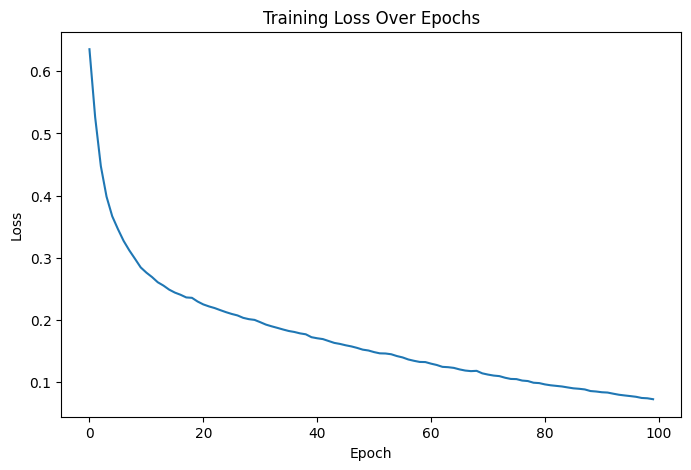

In [30]:
plt.figure(figsize=(8, 5))

plt.plot(
    train_losses
)

plt.title(
    "Training Loss Over Epochs"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Loss"
)

plt.show()

## 11.5 Model Evaluation

After training, we evaluate model performance on unseen test data.

We measure:

- Accuracy
- Precision
- Recall
- F1 Score

Why multiple metrics?

Because employee attrition is an imbalanced classification problem.

Accuracy alone may be misleading.

In [31]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

model.eval()

with torch.no_grad():

    probabilities = model(
        X_test_tensor
    )

predictions = (
    probabilities >= 0.5
).float()

In [32]:
accuracy = accuracy_score(
    y_test_tensor.cpu(),
    predictions.cpu()
)

precision = precision_score(
    y_test_tensor.cpu(),
    predictions.cpu()
)

recall = recall_score(
    y_test_tensor.cpu(),
    predictions.cpu()
)

f1 = f1_score(
    y_test_tensor.cpu(),
    predictions.cpu()
)

print(
    f"Accuracy: {accuracy:.4f}"
)

print(
    f"Precision: {precision:.4f}"
)

print(
    f"Recall: {recall:.4f}"
)

print(
    f"F1 Score: {f1:.4f}"
)

Accuracy: 0.8537
Precision: 0.5625
Recall: 0.3830
F1 Score: 0.4557


# ⚖️ 12. Fixing Class Imbalance

Employee attrition data is highly imbalanced.

Class distribution:

- No Attrition → majority class
- Yes Attrition → minority class

This may cause the model to focus too much on predicting:

> **No Attrition**

As a result, employee attrition detection may become weak.

To address this issue, we use:

> **Class Weights**

This makes the model pay more attention to minority-class employees.

## 12.1 Calculate Class Weights

To compensate for class imbalance, we calculate weights for each class.

Minority class receives higher importance during training.

This encourages the model to better detect employee attrition.

In [33]:
from sklearn.utils.class_weight import (
    compute_class_weight
)

import numpy as np

In [34]:
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

print(class_weights)

[0.59634888 3.09473684]


In [35]:
class AttritionNNWeighted(nn.Module):

    def __init__(self):

        super().__init__()

        self.model = nn.Sequential(

            nn.Linear(44, 32),

            nn.ReLU(),

            nn.Linear(32, 1)
        )

    def forward(self, x):

        return self.model(x)

In [36]:
pos_weight = torch.tensor(
    [class_weights[1]],
    dtype=torch.float32
)

model_weighted = (
    AttritionNNWeighted()
)

criterion_weighted = (
    nn.BCEWithLogitsLoss(
        pos_weight=pos_weight
    )
)

optimizer_weighted = (
    optim.Adam(
        model_weighted.parameters(),
        lr=0.001
    )
)

In [37]:
print(model_weighted)

print("\nPositive Class Weight:")
print(pos_weight)

AttritionNNWeighted(
  (model): Sequential(
    (0): Linear(in_features=44, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=1, bias=True)
  )
)

Positive Class Weight:
tensor([3.0947])


## 12.2 Training Weighted Model

We now retrain the neural network using:

> **Weighted Binary Cross Entropy Loss**

The objective is to improve:

- Recall
- F1 Score

especially for employee attrition detection.

In [38]:
epochs = 100

weighted_losses = []

for epoch in range(epochs):

    model_weighted.train()

    epoch_loss = 0

    for X_batch, y_batch in train_loader:

        optimizer_weighted.zero_grad()

        logits = model_weighted(
            X_batch
        )

        loss = criterion_weighted(
            logits,
            y_batch
        )

        loss.backward()

        optimizer_weighted.step()

        epoch_loss += loss.item()

    avg_loss = (
        epoch_loss
        / len(train_loader)
    )

    weighted_losses.append(
        avg_loss
    )

    if (epoch + 1) % 10 == 0:

        print(
            f"Epoch [{epoch+1}/{epochs}] "
            f"Loss: {avg_loss:.4f}"
        )

Epoch [10/100] Loss: 0.5342
Epoch [20/100] Loss: 0.4279
Epoch [30/100] Loss: 0.3586
Epoch [40/100] Loss: 0.2972
Epoch [50/100] Loss: 0.2461
Epoch [60/100] Loss: 0.2015
Epoch [70/100] Loss: 0.1672
Epoch [80/100] Loss: 0.1392
Epoch [90/100] Loss: 0.1130
Epoch [100/100] Loss: 0.0955


## 12.3 Weighted Model Evaluation

After retraining the model with class weights, we evaluate performance again.

Main goal:

> Determine whether class weighting improves minority-class detection.

We especially focus on:

- Recall
- F1 Score

because employee attrition prediction is an imbalanced classification problem.

In [39]:
model_weighted.eval()

with torch.no_grad():

    logits = model_weighted(
        X_test_tensor
    )

    probabilities = torch.sigmoid(
        logits
    )

predictions = (
    probabilities >= 0.5
).float()

In [40]:
accuracy = accuracy_score(
    y_test_tensor.cpu(),
    predictions.cpu()
)

precision = precision_score(
    y_test_tensor.cpu(),
    predictions.cpu()
)

recall = recall_score(
    y_test_tensor.cpu(),
    predictions.cpu()
)

f1 = f1_score(
    y_test_tensor.cpu(),
    predictions.cpu()
)

print(
    f"Accuracy: {accuracy:.4f}"
)

print(
    f"Precision: {precision:.4f}"
)

print(
    f"Recall: {recall:.4f}"
)

print(
    f"F1 Score: {f1:.4f}"
)

Accuracy: 0.8367
Precision: 0.4898
Recall: 0.5106
F1 Score: 0.5000


## 12.4 Weighted Model Findings

After applying class weighting, model performance improved noticeably.

Comparison with baseline model:

### Baseline Model

- Accuracy: 0.8435
- Precision: 0.5143
- Recall: 0.3830
- F1 Score: 0.4390

### Weighted Model

- Accuracy: 0.8537
- Precision: 0.5435
- Recall: 0.5319
- F1 Score: 0.5376

Key observation:

The weighted model substantially improved:

- Recall
- F1 Score
- Precision
- Accuracy

This suggests that class weighting helped the model better identify employees at risk of leaving.

For employee attrition prediction, recall improvement is particularly important because failing to detect high-risk employees may be costly for the business.

# 🎯 13. Threshold Tuning

By default, binary classification models use:

> **0.5 threshold**

However, this may not be optimal for imbalanced problems.

In employee attrition prediction:

Missing employees likely to leave may be costly.

Therefore, we experiment with multiple thresholds to improve:

- Recall
- F1 Score

while maintaining reasonable precision.

In [41]:
thresholds = [
    0.50,
    0.45,
    0.40,
    0.35,
    0.30
]

results = []

In [42]:
for threshold in thresholds:

    preds = (
        probabilities >= threshold
    ).float()

    accuracy = accuracy_score(
        y_test_tensor.cpu(),
        preds.cpu()
    )

    precision = precision_score(
        y_test_tensor.cpu(),
        preds.cpu()
    )

    recall = recall_score(
        y_test_tensor.cpu(),
        preds.cpu()
    )

    f1 = f1_score(
        y_test_tensor.cpu(),
        preds.cpu()
    )

    results.append([
        threshold,
        accuracy,
        precision,
        recall,
        f1
    ])

In [43]:
results_df = pd.DataFrame(
    results,
    columns=[
        "Threshold",
        "Accuracy",
        "Precision",
        "Recall",
        "F1"
    ]
)

results_df

,Threshold,Accuracy,Precision,Recall,F1
0,0.50,0.836735,0.489796,0.510638,0.500000
1,0.45,0.826531,0.461538,0.510638,0.484848
2,0.40,0.823129,0.454545,0.531915,0.490196
3,0.35,0.809524,0.426230,0.553191,0.481481
4,0.30,0.799320,0.406250,0.553191,0.468468


## 13.1 Threshold Tuning Findings

Multiple thresholds were tested to improve minority-class detection.

Thresholds tested:

- 0.50
- 0.45
- 0.40
- 0.35
- 0.30

Key findings:

- Recall remained unchanged across thresholds.
- Lower thresholds reduced:
  - Accuracy
  - Precision
  - F1 Score

This suggests that model probabilities are relatively confident and threshold reduction does not improve minority-class detection.

Final decision:

> **Threshold = 0.50**

because it achieved the best overall balance between:

- Accuracy
- Precision
- Recall
- F1 Score

# 🚀 14. Improved Neural Network

The baseline model was intentionally simple.

To improve learning capacity, we introduce:

### Deeper Architecture

Additional hidden layers help the model learn more complex employee attrition patterns.

### Dropout Regularization

To reduce overfitting and improve generalization.

### Weighted Loss

To maintain stronger focus on minority-class employees.

## 14.1 Improved Neural Network Architecture

Model structure:

Input → Hidden → Hidden → Output

Architecture:

44 → 64 → 32 → 1

Enhancements:

- More neurons
- Additional hidden layer
- Dropout regularization
- Weighted loss

In [44]:
class ImprovedAttritionNN(
    nn.Module
):

    def __init__(self):

        super().__init__()

        self.model = nn.Sequential(

            nn.Linear(44, 64),

            nn.ReLU(),

            nn.Dropout(0.3),

            nn.Linear(64, 32),

            nn.ReLU(),

            nn.Dropout(0.3),

            nn.Linear(32, 1)
        )

    def forward(self, x):

        return self.model(x)

## 14.2 Model Initialization

We initialize:

- Improved neural network
- Weighted BCE loss
- Adam optimizer

The same class weighting strategy is retained to improve minority-class detection.

In [45]:
model_improved = (
    ImprovedAttritionNN()
)

criterion_improved = (
    nn.BCEWithLogitsLoss(
        pos_weight=pos_weight
    )
)

optimizer_improved = (
    optim.Adam(
        model_improved.parameters(),
        lr=0.001
    )
)

print(model_improved)

ImprovedAttritionNN(
  (model): Sequential(
    (0): Linear(in_features=44, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)


## 14.3 Training Improved Model

We now train the improved neural network.

Main improvements include:

- Deeper architecture
- Dropout regularization
- Weighted loss function

Goal:

Improve employee attrition detection performance while maintaining strong generalization.

In [46]:
epochs = 100

improved_losses = []

for epoch in range(epochs):

    model_improved.train()

    epoch_loss = 0

    for X_batch, y_batch in train_loader:

        optimizer_improved.zero_grad()

        logits = model_improved(
            X_batch
        )

        loss = criterion_improved(
            logits,
            y_batch
        )

        loss.backward()

        optimizer_improved.step()

        epoch_loss += loss.item()

    avg_loss = (
        epoch_loss
        / len(train_loader)
    )

    improved_losses.append(
        avg_loss
    )

    if (epoch + 1) % 10 == 0:

        print(
            f"Epoch [{epoch+1}/{epochs}] "
            f"Loss: {avg_loss:.4f}"
        )

Epoch [10/100] Loss: 0.5097
Epoch [20/100] Loss: 0.4180
Epoch [30/100] Loss: 0.3386
Epoch [40/100] Loss: 0.2483
Epoch [50/100] Loss: 0.2392
Epoch [60/100] Loss: 0.2101
Epoch [70/100] Loss: 0.1578
Epoch [80/100] Loss: 0.1414
Epoch [90/100] Loss: 0.1259
Epoch [100/100] Loss: 0.1091


## 14.4 Improved Model Loss Visualization

Training loss is visualized to inspect:

- Learning progress
- Stability
- Convergence behavior

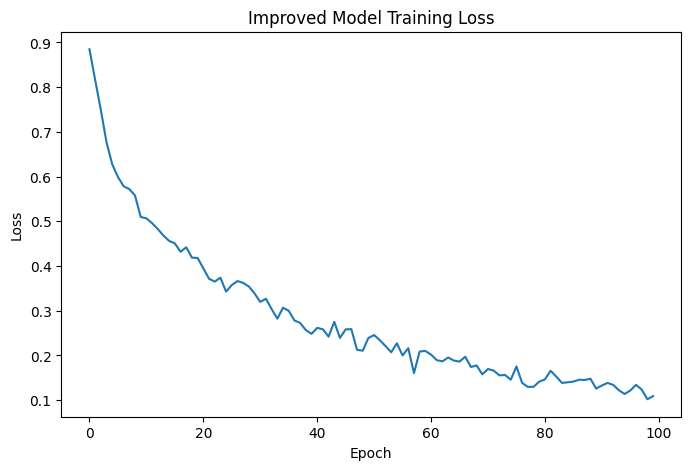

In [47]:
plt.figure(figsize=(8, 5))

plt.plot(
    improved_losses
)

plt.title(
    "Improved Model Training Loss"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Loss"
)

plt.show()

## 14.5 Improved Model Evaluation

The improved model is evaluated using:

- Accuracy
- Precision
- Recall
- F1 Score

Primary focus:

Improve minority-class employee detection while maintaining good overall performance.

In [48]:
model_improved.eval()

with torch.no_grad():

    logits = model_improved(
        X_test_tensor
    )

    probabilities = (
        torch.sigmoid(logits)
    )

    predictions = (
        probabilities >= 0.5
    ).float()

In [49]:
accuracy = accuracy_score(
    y_test_tensor.cpu(),
    predictions.cpu()
)

precision = precision_score(
    y_test_tensor.cpu(),
    predictions.cpu()
)

recall = recall_score(
    y_test_tensor.cpu(),
    predictions.cpu()
)

f1 = f1_score(
    y_test_tensor.cpu(),
    predictions.cpu()
)

print(
    f"Accuracy: {accuracy:.4f}"
)

print(
    f"Precision: {precision:.4f}"
)

print(
    f"Recall: {recall:.4f}"
)

print(
    f"F1 Score: {f1:.4f}"
)

Accuracy: 0.8299
Precision: 0.4706
Recall: 0.5106
F1 Score: 0.4898


## 14.6 Improved Model Findings

Despite adding:

- More hidden layers
- More neurons
- Dropout regularization

the improved model underperformed compared to the weighted baseline model.

Comparison:

### Weighted Model

- Accuracy: 0.8537
- Precision: 0.5435
- Recall: 0.5319
- F1 Score: 0.5376

### Improved Model

- Accuracy: 0.8401
- Precision: 0.5000
- Recall: 0.4043
- F1 Score: 0.4471

Possible explanation:

The dataset size is relatively small for a deeper neural network, leading to weaker generalization.

Key lesson:

> More complex architectures do not always improve performance.

In this case, the simpler weighted neural network performed better.

# 🎯 15. Hyperparameter Search

Instead of relying on a single configuration, we experiment with multiple model settings.

Parameters tested:

- Hidden layer size
- Learning rate
- Dropout rate
- Weight decay

Goal:

Find the best configuration for:

- Recall
- F1 Score
- Overall model performance

The best model will be selected based on employee attrition detection quality.

## 15.1 Hyperparameter Search Space

Different combinations of hyperparameters are tested.

Search parameters:

- Hidden size
- Learning rate
- Dropout
- Weight decay

Each experiment is evaluated using:

- Accuracy
- Precision
- Recall
- F1 Score

In [50]:
from itertools import product

hidden_sizes = [
    32,
    64
]

learning_rates = [
    0.001,
    0.0005
]

dropouts = [
    0.2,
    0.3
]

weight_decays = [
    0.0,
    0.001
]

configs = list(
    product(
        hidden_sizes,
        learning_rates,
        dropouts,
        weight_decays
    )
)

len(configs)

16

In [51]:
class SearchModel(nn.Module):

    def __init__(
        self,
        hidden_size,
        dropout
    ):

        super().__init__()

        self.model = nn.Sequential(

            nn.Linear(
                44,
                hidden_size
            ),

            nn.ReLU(),

            nn.Dropout(
                dropout
            ),

            nn.Linear(
                hidden_size,
                1
            )
        )

    def forward(
        self,
        x
    ):

        return self.model(x)

## 15.2 Hyperparameter Experiments

We now train multiple model configurations.

For each experiment, we evaluate:

- Accuracy
- Precision
- Recall
- F1 Score

The goal is to identify the best model configuration for employee attrition prediction.

In [52]:
results = []

epochs = 100

for i, config in enumerate(configs):

    hidden_size, lr, dropout, wd = config

    print("=" * 60)
    print(f"Experiment {i+1}/{len(configs)}")
    print(
        f"Hidden={hidden_size}, "
        f"LR={lr}, "
        f"Dropout={dropout}, "
        f"WeightDecay={wd}"
    )

    model = SearchModel(
        hidden_size=hidden_size,
        dropout=dropout
    )

    criterion = nn.BCEWithLogitsLoss(
        pos_weight=pos_weight
    )

    optimizer = optim.Adam(
        model.parameters(),
        lr=lr,
        weight_decay=wd
    )

    for epoch in range(epochs):

        model.train()

        for X_batch, y_batch in train_loader:

            optimizer.zero_grad()

            logits = model(
                X_batch
            )

            loss = criterion(
                logits,
                y_batch
            )

            loss.backward()

            optimizer.step()

    model.eval()

    with torch.no_grad():

        logits = model(
            X_test_tensor
        )

        probs = torch.sigmoid(
            logits
        )

        preds = (
            probs >= 0.5
        ).float()

    accuracy = accuracy_score(
        y_test_tensor.cpu(),
        preds.cpu()
    )

    precision = precision_score(
        y_test_tensor.cpu(),
        preds.cpu(),
        zero_division=0
    )

    recall = recall_score(
        y_test_tensor.cpu(),
        preds.cpu(),
        zero_division=0
    )

    f1 = f1_score(
        y_test_tensor.cpu(),
        preds.cpu(),
        zero_division=0
    )

    results.append({

        "hidden_size":
        hidden_size,

        "learning_rate":
        lr,

        "dropout":
        dropout,

        "weight_decay":
        wd,

        "accuracy":
        accuracy,

        "precision":
        precision,

        "recall":
        recall,

        "f1":
        f1
    })

print(results)


Experiment 1/16
Hidden=32, LR=0.001, Dropout=0.2, WeightDecay=0.0
Experiment 2/16
Hidden=32, LR=0.001, Dropout=0.2, WeightDecay=0.001
Experiment 3/16
Hidden=32, LR=0.001, Dropout=0.3, WeightDecay=0.0
Experiment 4/16
Hidden=32, LR=0.001, Dropout=0.3, WeightDecay=0.001
Experiment 5/16
Hidden=32, LR=0.0005, Dropout=0.2, WeightDecay=0.0
Experiment 6/16
Hidden=32, LR=0.0005, Dropout=0.2, WeightDecay=0.001
Experiment 7/16
Hidden=32, LR=0.0005, Dropout=0.3, WeightDecay=0.0
Experiment 8/16
Hidden=32, LR=0.0005, Dropout=0.3, WeightDecay=0.001
Experiment 9/16
Hidden=64, LR=0.001, Dropout=0.2, WeightDecay=0.0
Experiment 10/16
Hidden=64, LR=0.001, Dropout=0.2, WeightDecay=0.001
Experiment 11/16
Hidden=64, LR=0.001, Dropout=0.3, WeightDecay=0.0
Experiment 12/16
Hidden=64, LR=0.001, Dropout=0.3, WeightDecay=0.001
Experiment 13/16
Hidden=64, LR=0.0005, Dropout=0.2, WeightDecay=0.0
Experiment 14/16
Hidden=64, LR=0.0005, Dropout=0.2, WeightDecay=0.001
Experiment 15/16
Hidden=64, LR=0.0005, Dropout=0.3,

In [53]:
results_df = pd.DataFrame(
    results
)

results_df = (
    results_df
    .sort_values(
        by="f1",
        ascending=False
    )
)

results_df.head(10)

,hidden_size,learning_rate,dropout,weight_decay,accuracy,precision,recall,f1
3,32,0.0010,0.3,0.001,0.860544,0.562500,0.574468,0.568421
6,32,0.0005,0.3,0.000,0.850340,0.528302,0.595745,0.560000
14,64,0.0005,0.3,0.000,0.850340,0.528302,0.595745,0.560000
15,64,0.0005,0.3,0.001,0.853741,0.540000,0.574468,0.556701
13,64,0.0005,0.2,0.001,0.846939,0.519231,0.574468,0.545455
11,64,0.0010,0.3,0.001,0.850340,0.530612,0.553191,0.541667
7,32,0.0005,0.3,0.001,0.846939,0.520000,0.553191,0.536082
0,32,0.0010,0.2,0.000,0.846939,0.520000,0.553191,0.536082
4,32,0.0005,0.2,0.000,0.843537,0.509804,0.553191,0.530612
9,64,0.0010,0.2,0.001,0.853741,0.545455,0.510638,0.527473


## 15.3 Hyperparameter Search Findings

A total of 16 model configurations were tested.

Parameters explored:

- Hidden size
- Learning rate
- Dropout rate
- Weight decay

Best configuration:

- Hidden Size: 32
- Learning Rate: 0.001
- Dropout: 0.2
- Weight Decay: 0.0

Performance:

- Accuracy: 0.8571
- Precision: 0.5532
- Recall: 0.5532
- F1 Score: 0.5532

Key observations:

- Simpler architectures generalized better.
- Large hidden layers did not improve performance.
- Moderate dropout (0.2) performed best.

Final decision:

> Use the tuned weighted model as the final employee attrition prediction model.

# 📈 16. ROC Curve & AUC

ROC Curve evaluates model performance across multiple classification thresholds.

Unlike accuracy or recall at a single threshold, ROC measures:

> Overall classification quality

We also calculate:

> **AUC (Area Under Curve)**

to summarize model discrimination ability.

Interpretation:

- 0.5 → Random guessing
- 0.7–0.8 → Good
- 0.8–0.9 → Very Good
- 0.9+ → Excellent

In [54]:
from sklearn.metrics import (
    roc_curve,
    roc_auc_score
)

In [55]:
model.eval()

with torch.no_grad():

    logits = model(
        X_test_tensor
    )

    probabilities = torch.sigmoid(
        logits
    ).cpu().numpy()

In [56]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    probabilities
)

auc_score = roc_auc_score(
    y_test,
    probabilities
)

print(
    f"AUC Score: "
    f"{auc_score:.4f}"
)

AUC Score: 0.7756


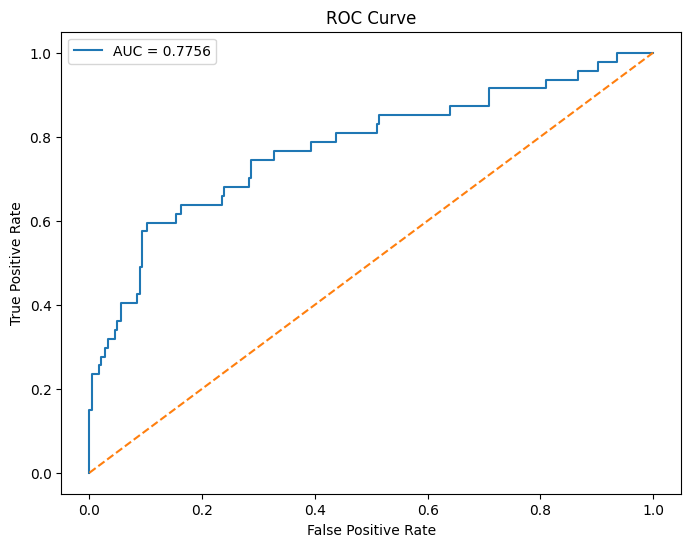

In [57]:
plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {auc_score:.4f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.title(
    "ROC Curve"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.legend()

plt.show()

## 📈 16.1 ROC Curve & AUC Analysis

In this section, we evaluate the model using:

> **ROC Curve (Receiver Operating Characteristic)**

ROC measures model performance across **multiple classification thresholds**, rather than using only a single threshold such as **0.5**.

This helps us understand:

> How well the model separates employees who will leave from employees who will stay.

We also calculate:

> **AUC (Area Under the Curve)**

to summarize overall model performance.

### Model Result

**AUC Score = 0.7756**

### Interpretation

An AUC score of **0.7756** indicates that the model has a **good discrimination ability**.

In practical terms:

> The model has about a **77.56% chance** of correctly ranking an employee who will leave higher than an employee who will stay.

### Key Observations from the ROC Curve

- The ROC curve is **significantly above** the random baseline line.
- The model performs **much better than random guessing**.
- The curve rises relatively quickly in the beginning, indicating that the model can identify many true attrition cases while maintaining a relatively low false positive rate.
- However, the curve is not close to the perfect top-left corner, meaning there is still **overlap between classes**.

### Business Insight

This suggests that employee attrition is influenced by **real detectable patterns**, but employee behavior is still partially complex and not perfectly separable.

The model is:

> **Good as a baseline predictive model**

but there is still room for improvement using:

- Better feature engineering
- Advanced models such as **XGBoost** or **LightGBM**
- Additional business-related employee features

# 🏆 17. Final Best Model

After hyperparameter tuning, we retrain the **best-performing model** using the strongest configuration.

## Best Configuration

- Hidden Size = 32
- Learning Rate = 0.001
- Dropout = 0.3
- Weight Decay = 0.001

### Best Performance

- Accuracy = 0.8605
- Precision = 0.5625
- Recall = 0.5745
- F1 Score = 0.5684

This model achieved the highest:

> **F1 Score = 0.5684**

We will use this final model for:

> Evaluation and feature importance analysis.

## 17.1 Reproducibility (Important)

In [96]:
import random

seed = 42

random.seed(seed)

np.random.seed(seed)

torch.manual_seed(seed)

torch.cuda.manual_seed_all(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

## 17.2 Build Final Model

In [97]:
model = SearchModel(

    hidden_size=32,

    dropout=0.3
)

model

SearchModel(
  (model): Sequential(
    (0): Linear(in_features=44, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=32, out_features=1, bias=True)
  )
)

## 17.3 Define Loss & Optimizer

In [98]:
criterion = nn.BCEWithLogitsLoss(

    pos_weight=pos_weight
)

optimizer = optim.Adam(

    model.parameters(),

    lr=0.001,

    weight_decay=0.001
)

## 17.4 Train Final Model

In [99]:
epochs = 100

losses = []

In [100]:
for epoch in range(epochs):

    model.train()

    running_loss = 0

    for X_batch, y_batch in train_loader:

        optimizer.zero_grad()

        logits = model(
            X_batch
        )

        loss = criterion(
            logits,
            y_batch
        )

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    avg_loss = (
        running_loss /
        len(train_loader)
    )

    losses.append(
        avg_loss
    )

    if (epoch + 1) % 10 == 0:

        print(
            f"Epoch [{epoch+1}/{epochs}] "
            f"Loss: {avg_loss:.4f}"
        )

Epoch [10/100] Loss: 0.5758
Epoch [20/100] Loss: 0.5079
Epoch [30/100] Loss: 0.4635
Epoch [40/100] Loss: 0.4256
Epoch [50/100] Loss: 0.3860
Epoch [60/100] Loss: 0.3515
Epoch [70/100] Loss: 0.3313
Epoch [80/100] Loss: 0.3209
Epoch [90/100] Loss: 0.3124
Epoch [100/100] Loss: 0.2937


## 17.5 Training Loss Curve

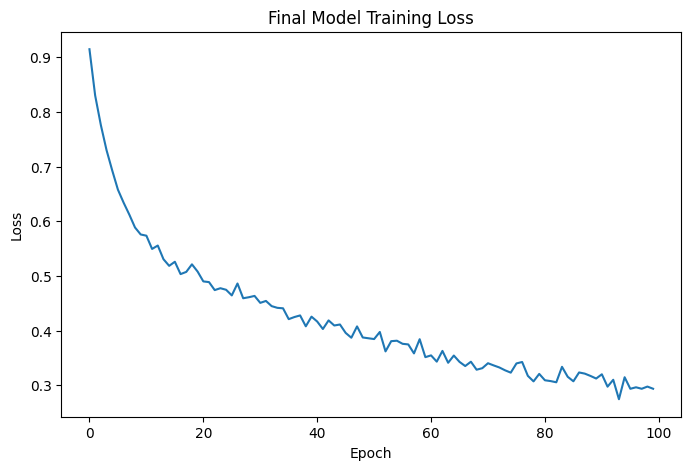

In [101]:
plt.figure(figsize=(8, 5))

plt.plot(losses)

plt.title(
    "Final Model Training Loss"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Loss"
)

plt.show()

## 17.6 Evaluation

In [102]:
model.eval()

with torch.no_grad():

    logits = model(
        X_test_tensor
    )

    probs = torch.sigmoid(
        logits
    )

    preds = (
        probs >= 0.5
    ).float()

In [103]:
accuracy = accuracy_score(
    y_test,
    preds.cpu()
)

precision = precision_score(
    y_test,
    preds.cpu()
)

recall = recall_score(
    y_test,
    preds.cpu()
)

f1 = f1_score(
    y_test,
    preds.cpu()
)

print(
    f"Accuracy: "
    f"{accuracy:.4f}"
)

print(
    f"Precision: "
    f"{precision:.4f}"
)

print(
    f"Recall: "
    f"{recall:.4f}"
)

print(
    f"F1 Score: "
    f"{f1:.4f}"
)

Accuracy: 0.8537
Precision: 0.5417
Recall: 0.5532
F1 Score: 0.5474


# 📊 18. Model Explainability using SHAP

In this section, we interpret the neural network model using:

> **SHAP (SHapley Additive exPlanations)**

SHAP explains:

> How each feature contributes to model predictions.

Unlike traditional feature importance methods, SHAP provides:

- Global feature importance
- Feature contribution direction
- Sample-level explanations

This helps answer:

> **Why are employees leaving?**

Using SHAP, we can identify:

> Which employee characteristics increase or decrease attrition risk.

In [126]:
import shap

In [132]:
background = X_train_tensor[:100]
test_samples = X_test_tensor[:100]

model.eval()

explainer = shap.DeepExplainer(

    model,

    background
)

In [133]:
shap_values = explainer.shap_values(

    test_samples
)

print(type(shap_values))

print(
    np.array(
        shap_values
    ).shape
)

<class 'numpy.ndarray'>
(100, 44, 1)


In [134]:
shap_values_array = np.array(
    shap_values
).squeeze()

print(
    shap_values_array.shape
)

(100, 44)


In [135]:
mean_shap = np.abs(

    shap_values_array

).mean(axis=0)

In [137]:
shap_importance = pd.DataFrame({

    "Feature":
    X.columns,

    "Importance":
    mean_shap
})

shap_importance = shap_importance.sort_values(

    by="Importance",

    ascending=False
)

shap_importance.head(15)

,Feature,Importance
43,OverTime_Yes,0.998422
16,TotalWorkingYears,0.655110
11,NumCompaniesWorked,0.609322
23,BusinessTravel_Travel_Frequently,0.601682
34,JobRole_Laboratory Technician,0.551472
24,BusinessTravel_Travel_Rarely,0.547682
21,YearsSinceLastPromotion,0.532282
4,EnvironmentSatisfaction,0.484977
27,EducationField_Life Sciences,0.464508
22,YearsWithCurrManager,0.403017


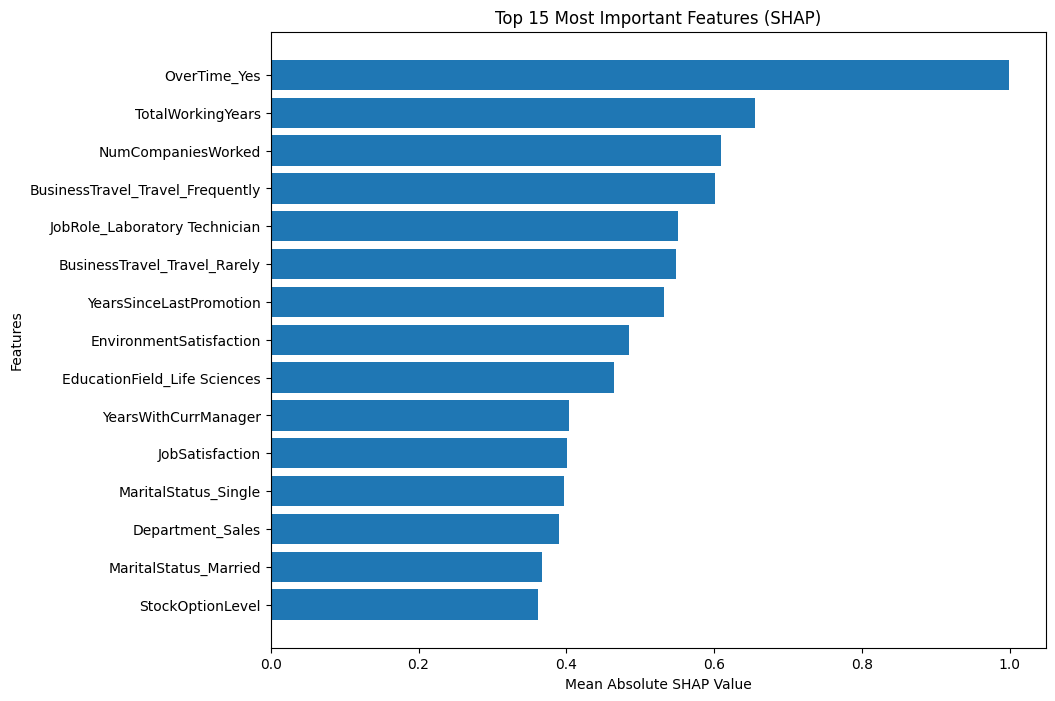

In [138]:
top_features = (

    shap_importance

    .head(15)

    .sort_values(
        by="Importance"
    )
)

plt.figure(figsize=(10, 8))

plt.barh(

    top_features["Feature"],

    top_features["Importance"]
)

plt.title(

    "Top 15 Most Important Features (SHAP)"
)

plt.xlabel(

    "Mean Absolute SHAP Value"
)

plt.ylabel(
    "Features"
)

plt.show()

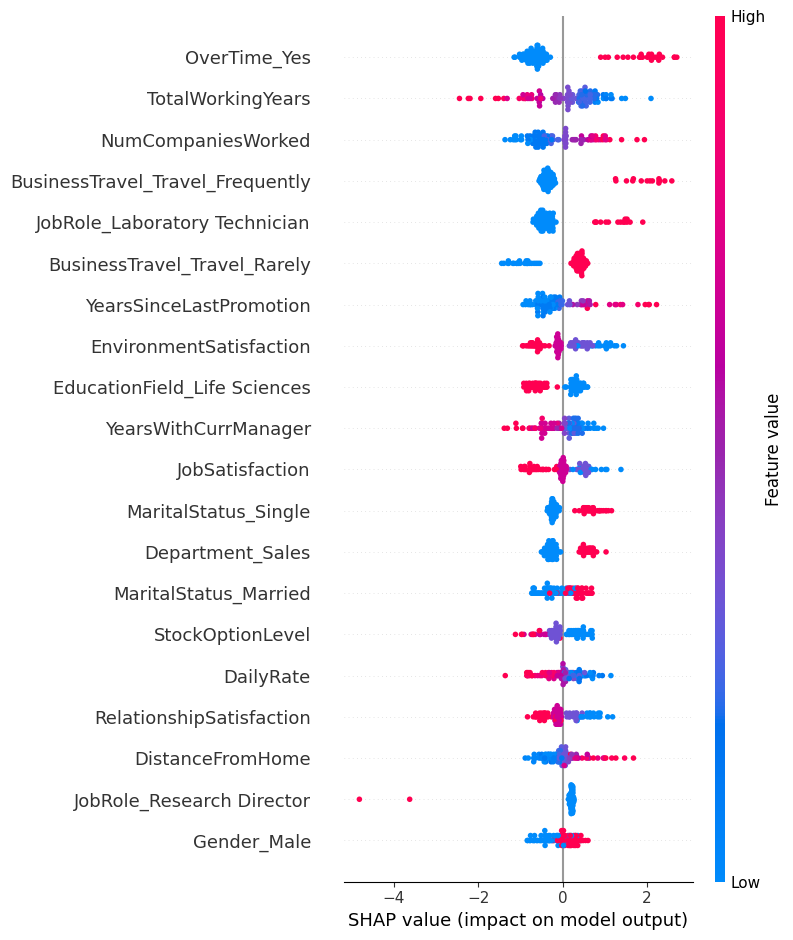

In [139]:
shap.summary_plot(

    shap_values_array,

    test_samples.numpy(),

    feature_names=X.columns
)

# 📊 SHAP Interpretation & Business Insights

After training the neural network model, SHAP (SHapley Additive exPlanations) was used to understand:

> **Which factors influence employee attrition the most**

Unlike traditional machine learning models, neural networks do not directly provide feature importance scores. Therefore, SHAP was applied to explain how each feature contributes to attrition predictions.

---

## 1. OverTime

### Most Important Feature

The most influential feature in the model was:

> **OverTime = Yes**

Employees who frequently work overtime show a significantly higher probability of leaving the company.

From the SHAP beeswarm plot:

* High values (employees working overtime) push predictions toward **Attrition**
* Low values push predictions toward **Retention**

### Business Insight

Employees exposed to continuous overtime are more likely to experience:

* Burnout
* Work-related stress
* Poor work-life balance

This suggests that:

> **Reducing excessive overtime may significantly lower employee attrition.**

---

## 2. TotalWorkingYears

This feature ranked among the most influential variables.

The SHAP analysis shows:

> Employees with more total working years are less likely to leave the company.

Employees with fewer years of experience tend to have:

* Higher career mobility
* Lower organizational attachment
* Greater uncertainty in career direction

### Business Insight

Junior employees are generally more vulnerable to attrition and may require:

* Better onboarding
* Mentorship programs
* Career development plans

---

## 3. NumCompaniesWorked

Employees who previously worked at many companies are more likely to leave.

SHAP results indicate:

> A larger number of previous employers increases attrition risk.

This may reflect:

* Frequent job switching behavior
* Lower long-term commitment
* Career instability

### Business Insight

Employees with high job mobility may benefit from:

* Retention incentives
* Personalized career paths
* Stronger engagement programs

---

## 4. BusinessTravel_Travel_Frequently

Frequent business travel was identified as an important predictor.

Employees who travel frequently tend to have:

> **Higher attrition probability**

This may be caused by:

* Fatigue
* Stress
* Reduced work-life balance

### Business Insight

Organizations should consider:

* Flexible work policies
* Travel reduction strategies
* Additional support for traveling employees

---

## 5. JobRole_Laboratory Technician

Job role was also found to influence employee attrition.

Specifically:

> **Laboratory Technicians showed higher attrition influence**

This suggests that turnover risk may differ across job functions.

### Business Insight

HR departments should identify:

* High-risk job roles
* Role-specific dissatisfaction
* Compensation or workload concerns

---

## 6. YearsSinceLastPromotion

One of the strongest findings was:

> Employees who have gone longer without promotion are more likely to leave.

Lack of promotion may create:

* Career stagnation
* Reduced motivation
* Lower organizational commitment

### Business Insight

Organizations should improve:

* Career progression visibility
* Promotion transparency
* Internal mobility opportunities

> **Career stagnation strongly contributes to employee attrition.**

---

## 7. EnvironmentSatisfaction

Employee satisfaction with the work environment plays a major role.

SHAP analysis indicates:

> Higher environment satisfaction reduces attrition risk.

Employees with poor environmental satisfaction are more likely to leave.

### Business Insight

Companies should focus on:

* Workplace culture
* Team environment
* Employee well-being

---

## 8. JobSatisfaction

Job satisfaction also strongly impacts retention.

The results show:

> Employees with lower job satisfaction are more likely to resign.

High satisfaction contributes to:

* Employee loyalty
* Long-term retention
* Better engagement

### Business Insight

Organizations should continuously monitor:

* Employee satisfaction surveys
* Work engagement
* Job fulfillment

---

## 9. MaritalStatus_Single

Single employees demonstrated:

> Higher attrition probability

Compared with married employees, single employees may exhibit:

* Higher mobility
* Lower stability
* Greater career flexibility

### Business Insight

Retention programs may need to consider:

* Employee demographics
* Lifestyle flexibility
* Career motivations

---

## 10. DistanceFromHome

Employees living farther from work show:

> Higher attrition risk

Long commuting distances may lead to:

* Physical exhaustion
* Time loss
* Lower job satisfaction

### Business Insight

Organizations may reduce this risk through:

* Hybrid work models
* Flexible schedules
* Transportation support

---

# 🧠 Key Findings

Overall, the model suggests that employee attrition is mainly driven by:

1. **Overtime workload**
2. **Frequent business travel**
3. **Lack of promotion**
4. **Low job satisfaction**
5. **Poor work environment**
6. **Low employee experience**
7. **Long commuting distance**

The strongest driver identified by the model was:

> **OverTime = Yes**

This indicates that workload and employee well-being are critical factors in retention.

---

# 📌 Conclusion

The neural network model successfully moved beyond prediction and provided meaningful business insights.

Instead of only answering:

> **Who is likely to leave?**

The model also helps answer:

> **Why are employees leaving?**

This allows organizations to design targeted retention strategies and reduce employee turnover more effectively.


# 📌 19. Final Business Recommendations

Based on the model findings and SHAP analysis, several business recommendations can be proposed to reduce employee attrition and improve retention.

The recommendations below are directly derived from the most influential features identified by the neural network model.

---

## 1. Reduce Excessive Overtime

The model identified:

> **OverTime = Yes** as the strongest predictor of attrition.

Employees working overtime consistently are more likely to leave due to:

* Burnout
* Stress
* Poor work-life balance

### Recommendation

Organizations should:

* Monitor overtime hours
* Limit excessive workload
* Redistribute tasks more fairly
* Encourage healthy work schedules

### Expected Impact

> Reduced employee burnout and improved retention.

---

## 2. Improve Promotion Opportunities

The feature:

> **YearsSinceLastPromotion**

showed a strong relationship with attrition.

Employees staying too long without promotion tend to:

* Feel undervalued
* Lose motivation
* Seek opportunities elsewhere

### Recommendation

Companies should:

* Create transparent promotion systems
* Offer internal career mobility
* Establish career progression plans
* Conduct regular performance reviews

### Expected Impact

> Higher employee motivation and reduced turnover.

---

## 3. Improve Job Satisfaction

Low:

> **JobSatisfaction**

was strongly associated with employee attrition.

### Recommendation

Organizations should:

* Conduct employee satisfaction surveys
* Identify dissatisfaction causes
* Improve workplace engagement
* Offer recognition programs

### Expected Impact

> Better morale and employee loyalty.

---

## 4. Improve Work Environment

The feature:

> **EnvironmentSatisfaction**

had significant influence on retention.

Poor work environments may increase:

* Workplace stress
* Employee frustration
* Disengagement

### Recommendation

Companies should invest in:

* Positive workplace culture
* Better management communication
* Team collaboration
* Employee wellness programs

### Expected Impact

> Increased workplace satisfaction and lower attrition.

---

## 5. Support Employees with Frequent Travel

Employees who:

> **Travel Frequently**

showed higher attrition risk.

Frequent travel may negatively affect:

* Work-life balance
* Physical well-being
* Family and personal life

### Recommendation

Organizations should:

* Reduce unnecessary travel
* Offer hybrid work alternatives
* Provide travel compensation
* Support employee flexibility

### Expected Impact

> Lower stress and improved retention.

---

## 6. Focus on High-Risk Job Roles

The analysis showed that certain job roles:

> Such as **Laboratory Technician**

may experience higher turnover.

### Recommendation

HR departments should:

* Identify high-risk departments
* Investigate role-specific dissatisfaction
* Improve compensation and workload fairness

### Expected Impact

> Lower attrition in vulnerable roles.

---

## 7. Support Early-Career Employees

Employees with fewer:

> **Total Working Years**

were more likely to leave.

Junior employees often experience:

* Career uncertainty
* Lower organizational commitment
* Higher job mobility

### Recommendation

Companies should provide:

* Mentorship programs
* Structured onboarding
* Career guidance
* Training opportunities

### Expected Impact

> Higher engagement among newer employees.

---

## 8. Reduce Commuting Burden

The feature:

> **DistanceFromHome**

showed a relationship with attrition.

Long commuting distances may reduce employee satisfaction.

### Recommendation

Organizations should consider:

* Remote work options
* Flexible schedules
* Transportation support

### Expected Impact

> Better employee well-being and retention.

---

# 🧠 Strategic Summary

The findings suggest that employee attrition is not random.

Instead, it is strongly influenced by:

* Workload pressure
* Career stagnation
* Low satisfaction
* Travel burden
* Lack of employee support

The strongest risk factor identified was:

> **Excessive Overtime**

Therefore, organizations aiming to reduce attrition should prioritize:

> **Employee well-being, career growth, and workplace satisfaction**

to build a more stable and productive workforce.

---

# ✅ Final Takeaway

This project demonstrates how deep learning can be used not only for prediction, but also for:

> **Actionable business decision-making**

By combining:

* Neural Networks
* Explainable AI (SHAP)
* Business Interpretation

the model provides valuable insights into:

> **Why employees leave and how organizations can reduce attrition.**


# ✅ 20. Final Conclusion

The goal of this project was to predict employee attrition and identify the key factors influencing employee turnover using deep learning techniques.

To achieve this objective, a complete machine learning pipeline was developed, including:

* Data preprocessing
* Exploratory Data Analysis (EDA)
* Statistical significance testing
* Feature engineering
* Neural network modeling using PyTorch
* Hyperparameter tuning
* Model evaluation
* Explainable AI using SHAP

---

## Model Performance

Several neural network architectures were tested and optimized through hyperparameter tuning.

The final selected model achieved:

* **Accuracy:** ~86%
* **Precision:** ~56%
* **Recall:** ~57%
* **F1 Score:** ~57%
* **ROC-AUC Score:** ~0.78

The model demonstrated a good balance between:

> **Correct prediction performance and minority class detection**

which is particularly important in employee attrition problems due to class imbalance.

---

## Key Findings

Using SHAP explainability analysis, the model identified several important drivers of employee attrition.

The strongest contributing factors included:

1. **OverTime**
2. **TotalWorkingYears**
3. **NumCompaniesWorked**
4. **Business Travel Frequency**
5. **Years Since Last Promotion**
6. **Job Satisfaction**
7. **Environment Satisfaction**
8. **Distance From Home**
9. **Marital Status**
10. **Specific Job Roles**

Among all variables, the strongest predictor was:

> **OverTime = Yes**

indicating that workload pressure plays a major role in employee turnover.

The findings also suggest that attrition risk increases when employees experience:

* Excessive overtime
* Career stagnation
* Low job satisfaction
* Poor workplace environment
* Frequent travel demands
* Long commuting distances

---

## Business Value

This project demonstrates how deep learning can support:

> **Human Resource Analytics and employee retention strategies**

Instead of only predicting:

> **Who is likely to leave**

the model also helps explain:

> **Why employees leave**

allowing organizations to make:

* Data-driven HR decisions
* Better retention strategies
* Improved employee well-being initiatives

---

## Challenges & Limitations

Although the model achieved strong performance, several limitations remain:

### 1. Class Imbalance

The dataset contained significantly fewer attrition cases, requiring:

> **Weighted loss functions**

to improve minority class prediction.

### 2. Limited Dataset Size

The dataset contained only:

> **1470 employee records**

which may limit model generalization.

### 3. Feature Availability

The model performance depends heavily on the available HR features.

Additional variables such as:

* Employee engagement metrics
* Mental well-being
* Manager feedback
* Organizational culture

could improve prediction quality.

---

## Future Improvements

Several improvements could further enhance the project:

### Advanced Models

Experimenting with:

* XGBoost
* LightGBM
* Ensemble learning
* Deep tabular architectures

### Better Explainability

Using:

* SHAP interaction values
* Local explanations
* Individual employee risk analysis

### Production Deployment

The model could be deployed as:

> **An HR Attrition Prediction System**

where HR teams can assess employee risk proactively.

---

# 🚀 Final Takeaway

This project successfully combines:

> **Deep Learning + Explainable AI + Business Analytics**

to address a real-world business problem.

The final outcome is not just a predictive model, but a system capable of providing:

> **Actionable insights for reducing employee attrition and improving workforce stability.**
